# **Análise de Condições para ocorrência de Alzhaimer**
dataset do kaggle disponível em: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

# 0 Importações

## 0.1 Importação das bibliotecas

In [4]:
#Bibliotecas de manipulação de dados
import pandas as pd

#Bibliotecas de cálculos
import numpy as np
import math
from sklearn.metrics import confusion_matrix
from scipy import stats
from statsmodels.stats.power import TTestIndPower


#Bibliotecas de visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from seaborn_qqplot import pplot

#Utilidades
import inflection
from sklearn.model_selection import train_test_split
import os

## 0.2 Funções de apoio

In [6]:
def teste_shapiro(coluna, alpha):
    _, p = stats.shapiro(coluna)  
    return True if p > alpha else False

In [7]:
def teste_kruskal(col1, col2, alpha):
    _, p = stats.kruskal(col1, col2)
    return True if p > alpha else False

In [8]:
def teste_pearson(base, col_target, colunas, alpha):
    resultado = [0] * len(colunas)
    for j, col_j in enumerate(colunas):
        if col_j == col_target:
            continue
        _, p = stats.pearsonr(base[col_target], base[col_j])
        if p > alpha:
            resultado[j] = 1
    return resultado

In [9]:
def descrever_dependencia_pearson(resultados, col_target, colunas, origem, log):
    flag = sum(resultados) == 0
    if flag:
        mensagem = f"Na {origem} nenhuma coluna é dependente da {col_target}"
        print(mensagem)
        log.write(mensagem + "\n")
    else:
        for j, dep in enumerate(resultados):
            if dep:
                mensagem = f"Na {origem} as colunas {col_target} e {colunas[j]} são dependentes"
                print(mensagem)
                log.write(mensagem + "\n")

In [10]:
def salvar_densidade(main_columns, amostras, df_validacao, iteracao):
    rows = (len(main_columns) + 1) // 3
    columns = 3
    
    fig, axes = plt.subplots(rows, columns, figsize=(25, 5 * rows))
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    axes = axes.flatten()
    
    for i, col in enumerate(main_columns):
        for j, amostra in enumerate(amostras):
            sns.kdeplot(amostra[col], label=f"Amostra {j+1}", alpha=0.6, ax=axes[i])
        sns.kdeplot(df_validacao[col], label='Validacao', linestyle='--', ax=axes[i])
        axes[i].set_title(f'Densidade - {col}')
        axes[i].legend()
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.savefig(f"midia/simulacoes/densidade/simulacao{iteracao}.png", dpi=300, bbox_inches='tight')
    plt.close(fig) 

In [11]:
def salvar_boxplot(main_columns, amostras, df_validacao, iteracao):
    dados_box = pd.concat([
        amostras[0].assign(origem='Amostra 1'),
        amostras[1].assign(origem='Amostra 2'),
        amostras[2].assign(origem='Amostra 3'),
        df_validacao.assign(origem='Validacao')
    ])
    rows = (len(main_columns) + 1 )//3
    
    columns = 3
    
    fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
    plt.subplots_adjust(wspace=0.5,hspace=0.5)
    axes = axes.flatten()
    
    for i,col in enumerate(main_columns):
        sns.boxplot(data=dados_box, x='origem', y=col, ax=axes[i])
        axes[i].set_title(col)
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.savefig(f"midia/simulacoes/boxplots/simulacao{iteracao}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

In [12]:
def salvar_qqqplot(main_columns, amostras, df_validacao, iteracao):
    os.makedirs(f"midia/simulacoes/qqplots/simulacao{iteracao}", exist_ok=True)
    for linha in main_columns:
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        for i, amostra in enumerate(amostras):
            stats.probplot(amostra[linha], dist="norm", plot=axs[i])
            axs[i].set_title(f"QQ-Plot Amostra {i+1}")
        plt.suptitle(f"QQ-Plots para a variável {linha}", fontsize=16)
        fig.savefig(f"midia/simulacoes/qqplots/simulacao{iteracao}/{linha}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)

## 0.3 Carregamento dos dados

In [14]:
df_raw = pd.read_csv("alzheimers_disease_data.csv")
df_raw.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# 1.0 Descrição dos dados

In [16]:
df1 = df_raw.copy()

## Descrição das colunas

### **Informações do Paciente**  
- **PatientID**: Identificador único atribuído a cada paciente (4751 a 6900).  

### **Detalhes Demográficos**  
- **Age**: Idade dos pacientes, variando de 60 a 90 anos.  
- **Gender**: Gênero dos pacientes, onde 0 representa Masculino e 1 representa Feminino.  
- **Ethnicity**: Etnia dos pacientes, codificada da seguinte forma:  
  - 0: Caucasiano  
  - 1: Afro-Americano  
  - 2: Asiático  
  - 3: Outro  
- **EducationLevel**: Nível de educação dos pacientes, codificado da seguinte forma:  
  - 0: Nenhum  
  - 1: Ensino Médio  
  - 2: Bacharelado  
  - 3: Superior  

### **Fatores de Estilo de Vida**  
- **BMI**: Índice de Massa Corporal dos pacientes, variando de 15 a 40.  
- **Smoking**: Status de tabagismo, onde 0 indica Não e 1 indica Sim.  
- **AlcoholConsumption**: Consumo semanal de álcool em unidades, variando de 0 a 20.  
- **PhysicalActivity**: Atividade física semanal em horas, variando de 0 a 10.  
- **DietQuality**: Pontuação da qualidade da dieta, variando de 0 a 10.  
- **SleepQuality**: Pontuação da qualidade do sono, variando de 4 a 10.  

### **Histórico Médico**  
- **FamilyHistoryAlzheimers**: Histórico familiar de Doença de Alzheimer, onde 0 indica Não e 1 indica Sim.  
- **CardiovascularDisease**: Presença de doença cardiovascular, onde 0 indica Não e 1 indica Sim.  
- **Diabetes**: Presença de diabetes, onde 0 indica Não e 1 indica Sim.  
- **Depression**: Presença de depressão, onde 0 indica Não e 1 indica Sim.  
- **HeadInjury**: Histórico de lesão na cabeça, onde 0 indica Não e 1 indica Sim.  
- **Hypertension**: Presença de hipertensão, onde 0 indica Não e 1 indica Sim.  

### **Medições Clínicas**  
- **SystolicBP**: Pressão arterial sistólica, variando de 90 a 180 mmHg.  
- **DiastolicBP**: Pressão arterial diastólica, variando de 60 a 120 mmHg.  
- **CholesterolTotal**: Níveis totais de colesterol, variando de 150 a 300 mg/dL.  
- **CholesterolLDL**: Níveis de colesterol de lipoproteína de baixa densidade (LDL), variando de 50 a 200 mg/dL.  
- **CholesterolHDL**: Níveis de colesterol de lipoproteína de alta densidade (HDL), variando de 20 a 100 mg/dL.  
- **CholesterolTriglycerides**: Níveis de triglicerídeos, variando de 50 a 400 mg/dL.  

### **Avaliações Cognitivas e Funcionais**  
- **MMSE**: Pontuação do Mini Exame do Estado Mental, variando de 0 a 30. Pontuações mais baixas indicam comprometimento cognitivo.  
- **FunctionalAssessment**: Pontuação de avaliação funcional, variando de 0 a 10. Pontuações mais baixas indicam maior comprometimento.  
- **MemoryComplaints**: Presença de queixas de memória, onde 0 indica Não e 1 indica Sim.  
- **BehavioralProblems**: Presença de problemas comportamentais, onde 0 indica Não e 1 indica Sim.  
- **ADL**: Pontuação de atividades da vida diária, variando de 0 a 10. Pontuações mais baixas indicam maior comprometimento.  

### **Sintomas**  
- **Confusion**: Presença de confusão, onde 0 indica Não e 1 indica Sim.  
- **Disorientation**: Presença de desorientação, onde 0 indica Não e 1 indica Sim.  
- **PersonalityChanges**: Presença de mudanças de personalidade, onde 0 indica Não e 1 indica Sim.  
- **DifficultyCompletingTasks**: Presença de dificuldade em completar tarefas, onde 0 indica Não e 1 indica Sim.  
- **Forgetfulness**: Presença de esquecimento, onde 0 indica Não e 1 indica Sim.  

### **Informações de Diagnóstico**  
- **Diagnosis**: Status de diagnóstico da Doença de Alzheimer, onde 0 indica Não e 1 indica Sim.  

### **Informações Confidenciais**  
- **DoctorInCharge**: Esta coluna contém informações confidenciais sobre o médico responsável, com o valor "XXXConfid" para todos os pacientes.  

## 1.1 Renomeando colunas

In [20]:
colunas = df1.columns

snakecase = lambda x: inflection.underscore( x )

colunas_corrigidas = list(map(snakecase, colunas))

df1.columns = colunas_corrigidas
df1.columns

Index(['patient_id', 'age', 'gender', 'ethnicity', 'education_level', 'bmi',
       'smoking', 'alcohol_consumption', 'physical_activity', 'diet_quality',
       'sleep_quality', 'family_history_alzheimers', 'cardiovascular_disease',
       'diabetes', 'depression', 'head_injury', 'hypertension', 'systolic_bp',
       'diastolic_bp', 'cholesterol_total', 'cholesterol_ldl',
       'cholesterol_hdl', 'cholesterol_triglycerides', 'mmse',
       'functional_assessment', 'memory_complaints', 'behavioral_problems',
       'adl', 'confusion', 'disorientation', 'personality_changes',
       'difficulty_completing_tasks', 'forgetfulness', 'diagnosis',
       'doctor_in_charge'],
      dtype='object')

## 1.2 Dimensão dos dados

In [22]:
print(f"Linhas: {df1.shape[0]}\nColunas: {df1.shape[1]}")

Linhas: 2149
Colunas: 35


## 1.3 Tipo das colunas

In [24]:
df1.dtypes

patient_id                       int64
age                              int64
gender                           int64
ethnicity                        int64
education_level                  int64
bmi                            float64
smoking                          int64
alcohol_consumption            float64
physical_activity              float64
diet_quality                   float64
sleep_quality                  float64
family_history_alzheimers        int64
cardiovascular_disease           int64
diabetes                         int64
depression                       int64
head_injury                      int64
hypertension                     int64
systolic_bp                      int64
diastolic_bp                     int64
cholesterol_total              float64
cholesterol_ldl                float64
cholesterol_hdl                float64
cholesterol_triglycerides      float64
mmse                           float64
functional_assessment          float64
memory_complaints        

### 1.3.1 Ajustando as colunas

In [26]:
replace_gender = {0: "male", 1: "female"}
df1["gender"] = df1["gender"].map(replace_gender)

replace_ethnicity = {0: "caucasian", 1: "african american", 2: "asian", 3: "other"}
df1["ethnicity"] = df1["ethnicity"].map(replace_ethnicity)

replace_educational = {0: "none", 1: "high school", 2: "bachelor's", 3: "Higher"}
df1["education_level"] = df1["education_level"].map(replace_educational)

replace_binary = {0: "no", 1: "yes"}
cols_binary = ["smoking", "family_history_alzheimers", "cardiovascular_disease", "diabetes", "depression", "head_injury", "hypertension", "memory_complaints", "behavioral_problems", "confusion", "disorientation", "personality_changes", "difficulty_completing_tasks", "forgetfulness", "diagnosis"]

for col in cols_binary:
    df1[col] = df1[col].map(replace_binary)

In [27]:
df1.head()

,patient_id,age,gender,ethnicity,education_level,bmi,smoking,alcohol_consumption,physical_activity,diet_quality,...,memory_complaints,behavioral_problems,adl,confusion,disorientation,personality_changes,difficulty_completing_tasks,forgetfulness,diagnosis,doctor_in_charge
0,4751,73,male,caucasian,bachelor's,22.927749,no,13.297218,6.327112,1.347214,...,no,no,1.725883,no,no,no,yes,no,no,XXXConfid
1,4752,89,male,caucasian,none,26.827681,no,4.542524,7.619885,0.518767,...,no,no,2.592424,no,no,no,no,yes,no,XXXConfid
2,4753,73,male,other,high school,17.795882,no,19.555085,7.844988,1.826335,...,no,no,7.119548,no,yes,no,yes,no,no,XXXConfid
3,4754,74,female,caucasian,high school,33.800817,yes,12.209266,8.428001,7.435604,...,no,yes,6.481226,no,no,no,no,no,no,XXXConfid
4,4755,89,male,caucasian,none,20.716974,no,18.454356,6.310461,0.795498,...,no,no,0.014691,no,no,yes,yes,no,no,XXXConfid


## 1.4 Checagem de NAs

In [29]:
df1.isna().sum()

patient_id                     0
age                            0
gender                         0
ethnicity                      0
education_level                0
bmi                            0
smoking                        0
alcohol_consumption            0
physical_activity              0
diet_quality                   0
sleep_quality                  0
family_history_alzheimers      0
cardiovascular_disease         0
diabetes                       0
depression                     0
head_injury                    0
hypertension                   0
systolic_bp                    0
diastolic_bp                   0
cholesterol_total              0
cholesterol_ldl                0
cholesterol_hdl                0
cholesterol_triglycerides      0
mmse                           0
functional_assessment          0
memory_complaints              0
behavioral_problems            0
adl                            0
confusion                      0
disorientation                 0
personalit

## 1.5 Descrição dos dados

In [31]:
df_num = df1.select_dtypes( include=["int64", "float64"] )
df_cat = df1.select_dtypes( exclude=["int64", "float64"] )

### 1.5.1 Dados numéricos

In [33]:
medias = pd.DataFrame( df_num.apply( np.mean ) ).T 
medianas = pd.DataFrame( df_num.apply( np.median ) ).T 

In [34]:
desvio_padrao = pd.DataFrame( df_num.apply( np.std ) ).T
minimo = pd.DataFrame( df_num.apply( min ) ).T
maximo = pd.DataFrame( df_num.apply( max ) ).T
intervalo = pd.DataFrame( df_num.apply(lambda x: x.max() - x.min()) ).T
skew = pd.DataFrame( df_num.apply( lambda x: x.skew())).T 
kurtosis = pd.DataFrame( df_num.apply(lambda x: x.kurtosis() ) ).T

In [35]:
metricas_numericas = pd.concat( [minimo, maximo, intervalo, medias, medianas, desvio_padrao, skew, kurtosis] ).T.reset_index()
metricas_numericas.columns = (["atributos","minimo","maximo","intervalo","medias","medianas","desvio_padrao","skew","kurtosis"])

In [36]:
metricas_numericas

,atributos,minimo,maximo,intervalo,medias,medianas,desvio_padrao,skew,kurtosis
0,patient_id,4751.000000,6899.000000,2148.000000,5825.000000,5825.000000,620.362797,0.000000,-1.200000
1,age,60.000000,90.000000,30.000000,74.908795,75.000000,8.988129,0.045964,-1.189214
2,bmi,15.008851,39.992767,24.983916,27.655697,27.823924,7.215759,-0.026715,-1.184508
3,alcohol_consumption,0.002003,19.989293,19.987290,10.039442,9.934412,5.756570,0.018415,-1.202876
4,physical_activity,0.003616,9.987429,9.983813,4.920202,4.766424,2.856526,0.044973,-1.179196
5,diet_quality,0.009385,9.998346,9.988961,4.993138,5.076087,2.908378,-0.012058,-1.228962
6,sleep_quality,4.002629,9.999840,5.997212,7.051081,7.115646,1.763163,-0.069630,-1.212454
7,systolic_bp,90.000000,179.000000,89.000000,134.264774,134.000000,25.943314,0.009971,-1.197593
8,diastolic_bp,60.000000,119.000000,59.000000,89.847836,91.000000,17.588403,-0.054470,-1.235040
9,cholesterol_total,150.093316,299.993352,149.900037,225.197519,225.086430,42.532334,-0.018674,-1.156042


### 1.5.2 Dados categóricos

In [38]:
df_cat.apply(lambda x: x.unique().shape[0])

gender                         2
ethnicity                      4
education_level                4
smoking                        2
family_history_alzheimers      2
cardiovascular_disease         2
diabetes                       2
depression                     2
head_injury                    2
hypertension                   2
memory_complaints              2
behavioral_problems            2
confusion                      2
disorientation                 2
personality_changes            2
difficulty_completing_tasks    2
forgetfulness                  2
diagnosis                      2
doctor_in_charge               1
dtype: int64

# 2.0 Feature Engeneering

In [40]:
df2 = df1.copy()

# 3.0 Filtragem de variáveis

In [42]:
df3 = df2.copy()

In [43]:
#Remoção de colunas de ID e de valores únicos
cols_drop = ["patient_id", "doctor_in_charge"]
df2.drop(cols_drop, axis=1, inplace=True)

# 4.0 Analise exploratória

In [45]:
df4 = df3.copy()

## 4.1 Análise univariada

In [47]:
df_num = df4.select_dtypes( include=["int64", "float64"] )
df_cat = df4.select_dtypes( exclude=["int64", "float64"] )

### 4.1.1 Análise das variáveis numéricas

In [49]:
len(df_num.columns)

16

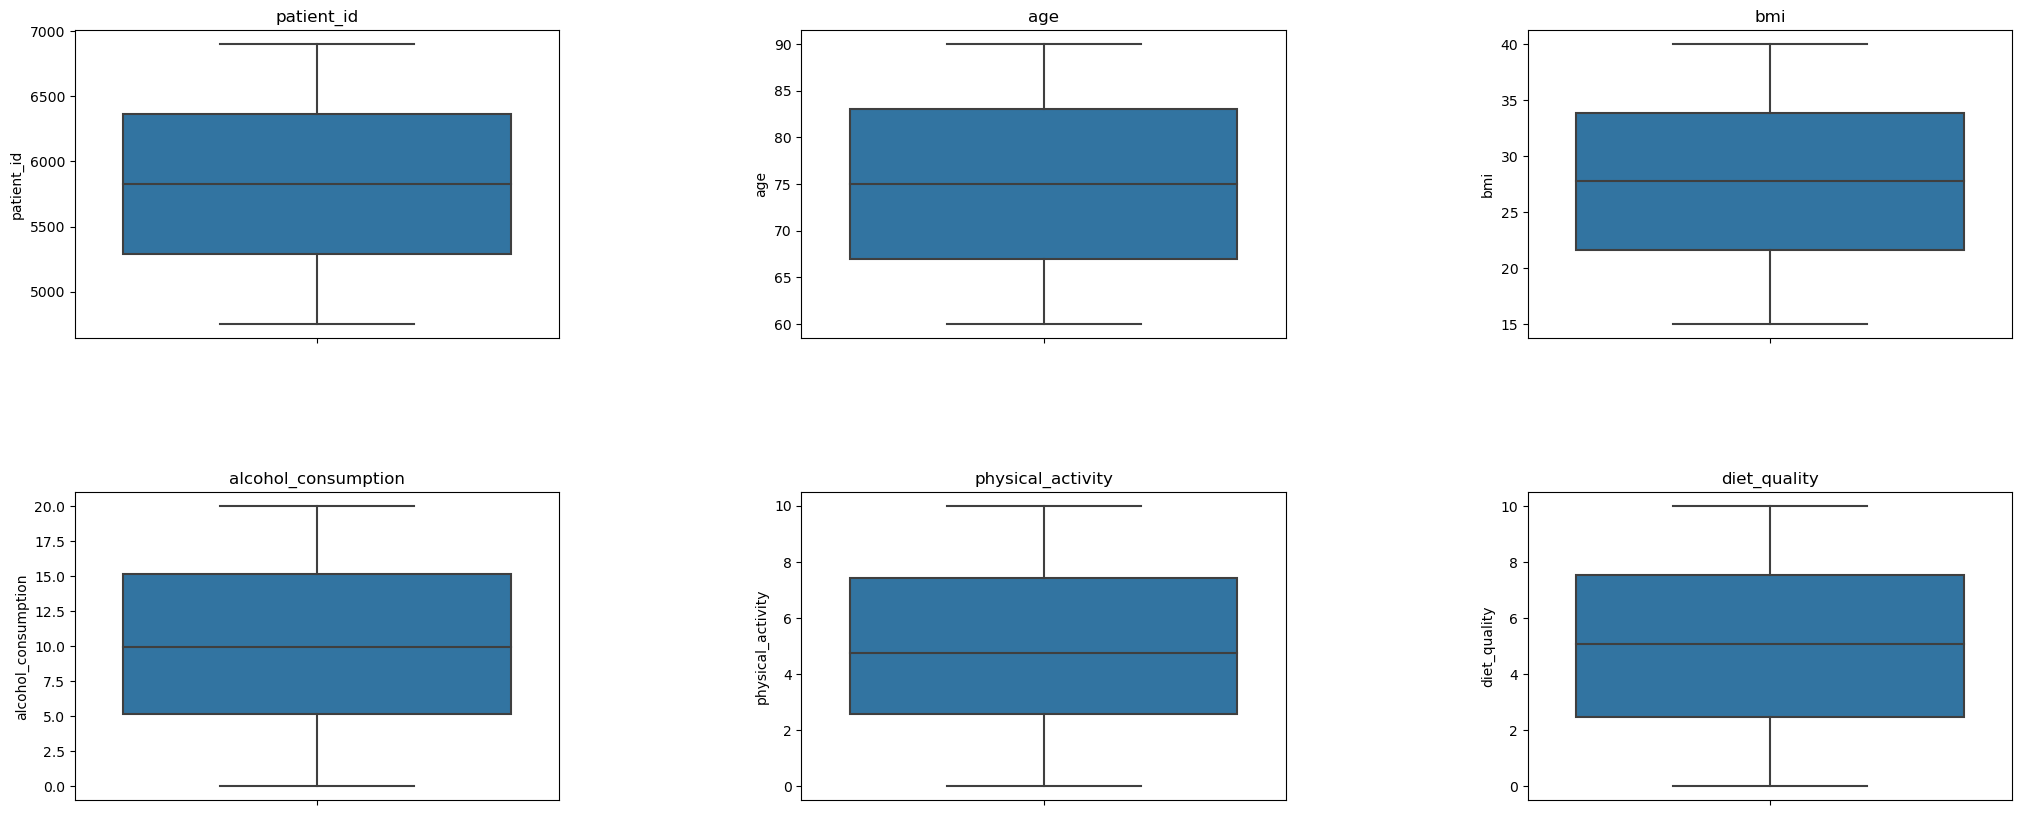

In [50]:
continuous_columns = df_num.columns[:6]
rows = (len(continuous_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(continuous_columns):
    sns.boxplot(df_num,y=str(col),ax=axes[i])
    axes[i].set_title(col)

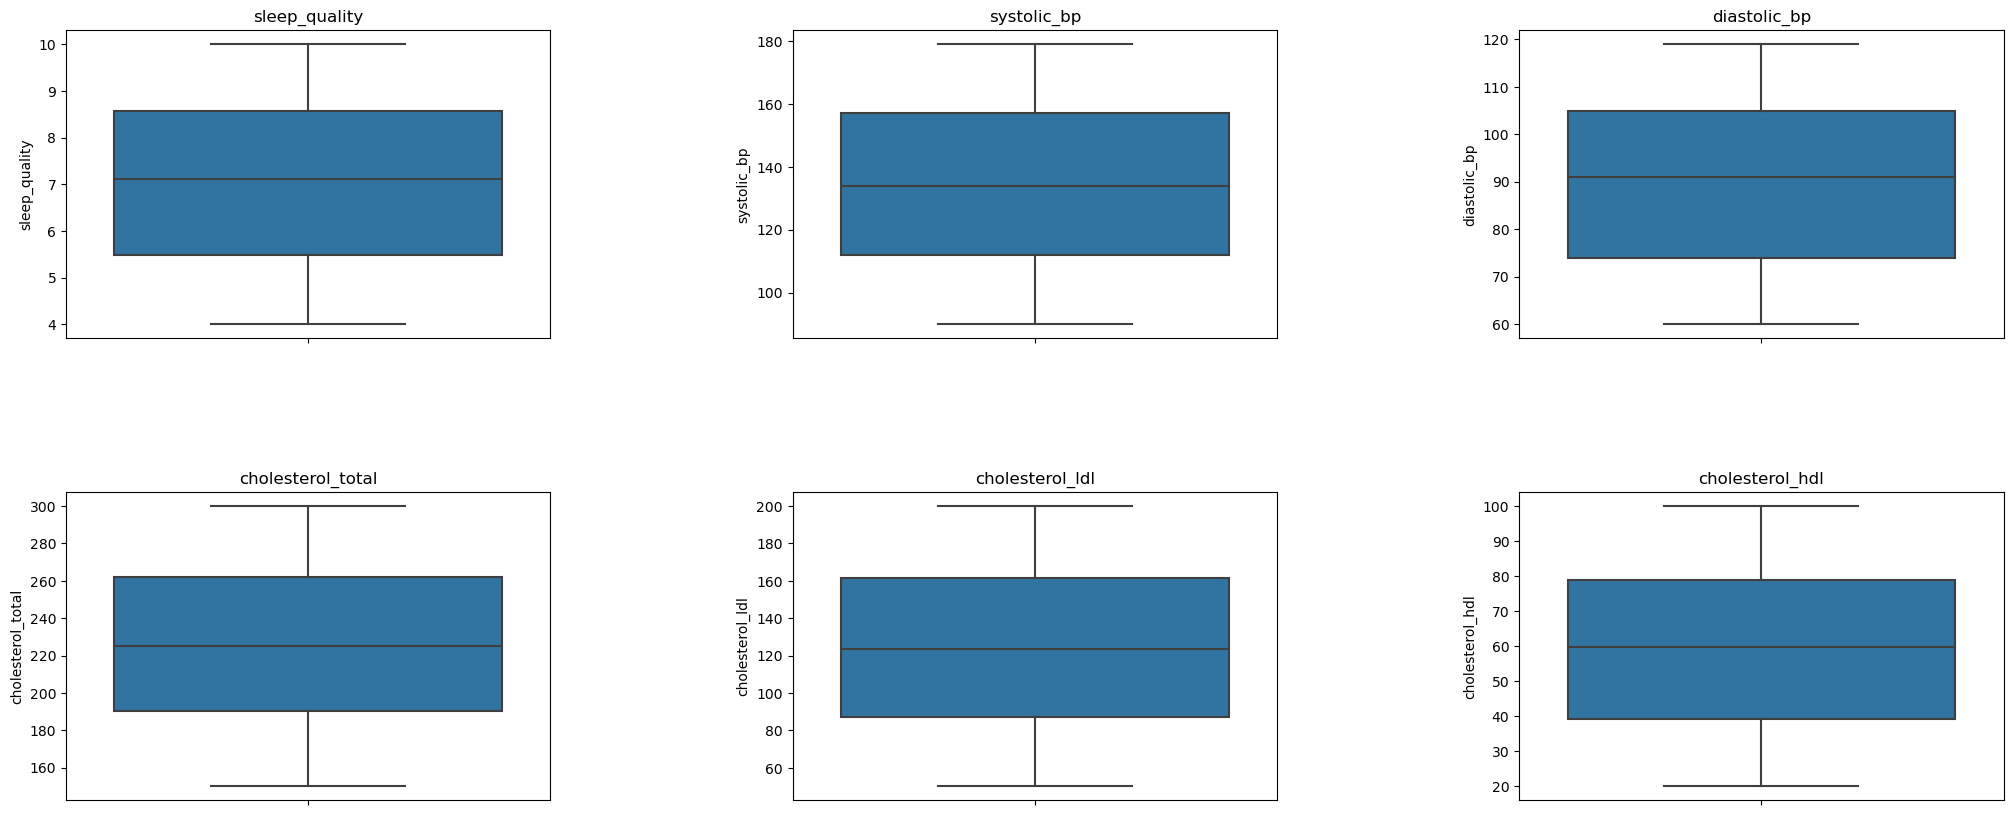

In [51]:
continuous_columns = df_num.columns[6:12]
rows = (len(continuous_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(continuous_columns):
    sns.boxplot(df_num,y=str(col),ax=axes[i])
    axes[i].set_title(col)

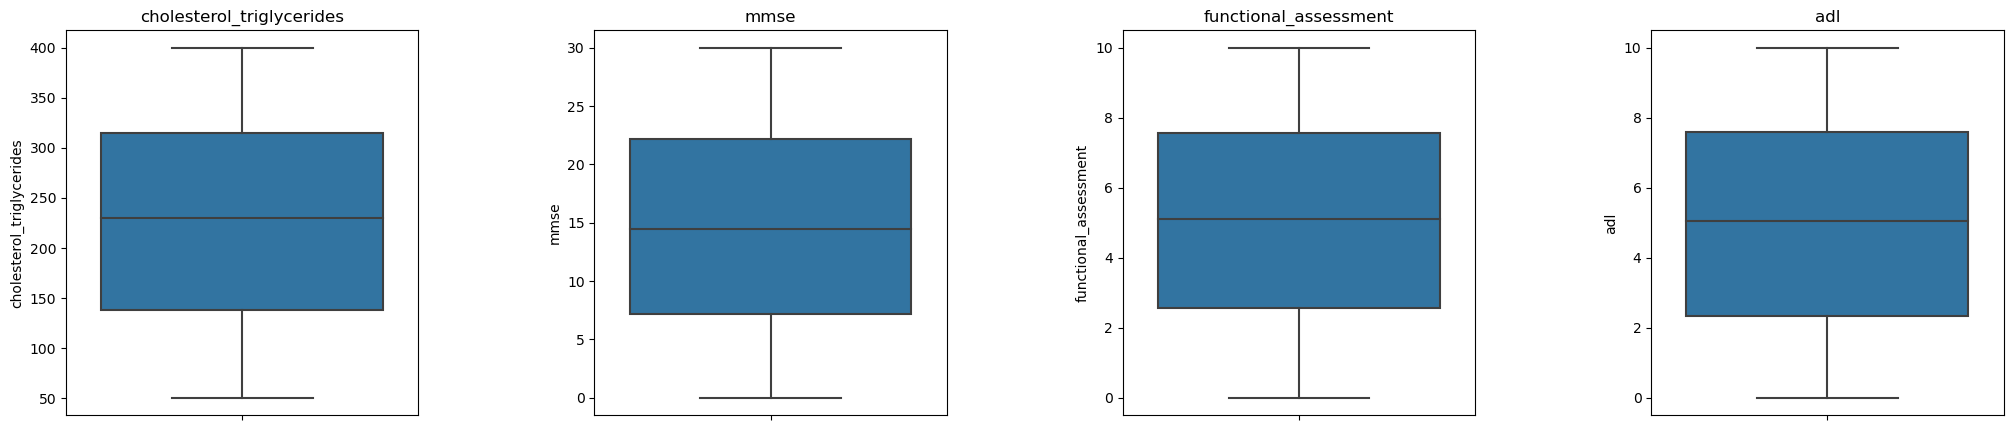

In [52]:
continuous_columns = df_num.columns[12:]
rows = (len(continuous_columns) + 1 )//3

columns = 4

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(continuous_columns):
    sns.boxplot(df_num,y=str(col),ax=axes[i])
    axes[i].set_title(col)

### 4.1.2 Análise das variáveis categoricas

## 4.2 Análise Bivariada

### 4.2.1 Análise das variáveis numéricas

### 4.2.1 Análise visando a ocorrência de Alzhaimer

# 5.0 Análise de métricas amostrais

In [58]:
df5 = df3.copy()
amostragem = df5.sample(frac=0.3)

In [59]:
df_num = amostragem.select_dtypes( include=["int64", "float64"] )
df_cat = amostragem.select_dtypes( exclude=["int64", "float64"] )

## 5.1 Descrição dos dados e boxplot

In [61]:
df_num.describe()

,patient_id,age,bmi,alcohol_consumption,physical_activity,diet_quality,sleep_quality,systolic_bp,diastolic_bp,cholesterol_total,cholesterol_ldl,cholesterol_hdl,cholesterol_triglycerides,mmse,functional_assessment,adl
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,5800.175194,75.176744,27.587396,9.804109,4.932201,5.111244,7.026549,136.328682,90.838760,225.894897,124.842685,59.356372,226.817905,14.409793,5.199362,4.959928
std,609.044235,8.994637,7.333132,5.689858,2.839967,2.913052,1.784225,25.277722,17.843228,42.199956,43.783415,22.708678,100.909494,8.631231,2.837558,2.974617
min,4751.000000,60.000000,15.008851,0.002003,0.045405,0.009385,4.020211,90.000000,60.000000,150.093316,50.282302,20.003434,50.461611,0.018022,0.000460,0.001288
25%,5265.000000,67.000000,21.349545,5.050398,2.543784,2.594078,5.432321,116.000000,75.000000,191.346035,87.631051,39.101220,138.279380,6.719022,2.908200,2.287524
50%,5759.000000,75.000000,27.830776,9.461524,4.638017,5.341956,7.113182,138.000000,92.000000,225.020797,124.483347,59.247771,231.198310,13.286117,5.317654,5.080035
75%,6324.000000,83.000000,33.855823,14.707459,7.354987,7.675199,8.538750,157.000000,107.000000,261.873127,161.812156,78.939050,309.621341,22.018309,7.545370,7.614610
max,6899.000000,90.000000,39.992767,19.984018,9.987429,9.980281,9.994079,179.000000,119.000000,299.873259,199.807179,99.770308,399.854322,29.833993,9.986410,9.999747


## 5.2 Matriz de Correlação

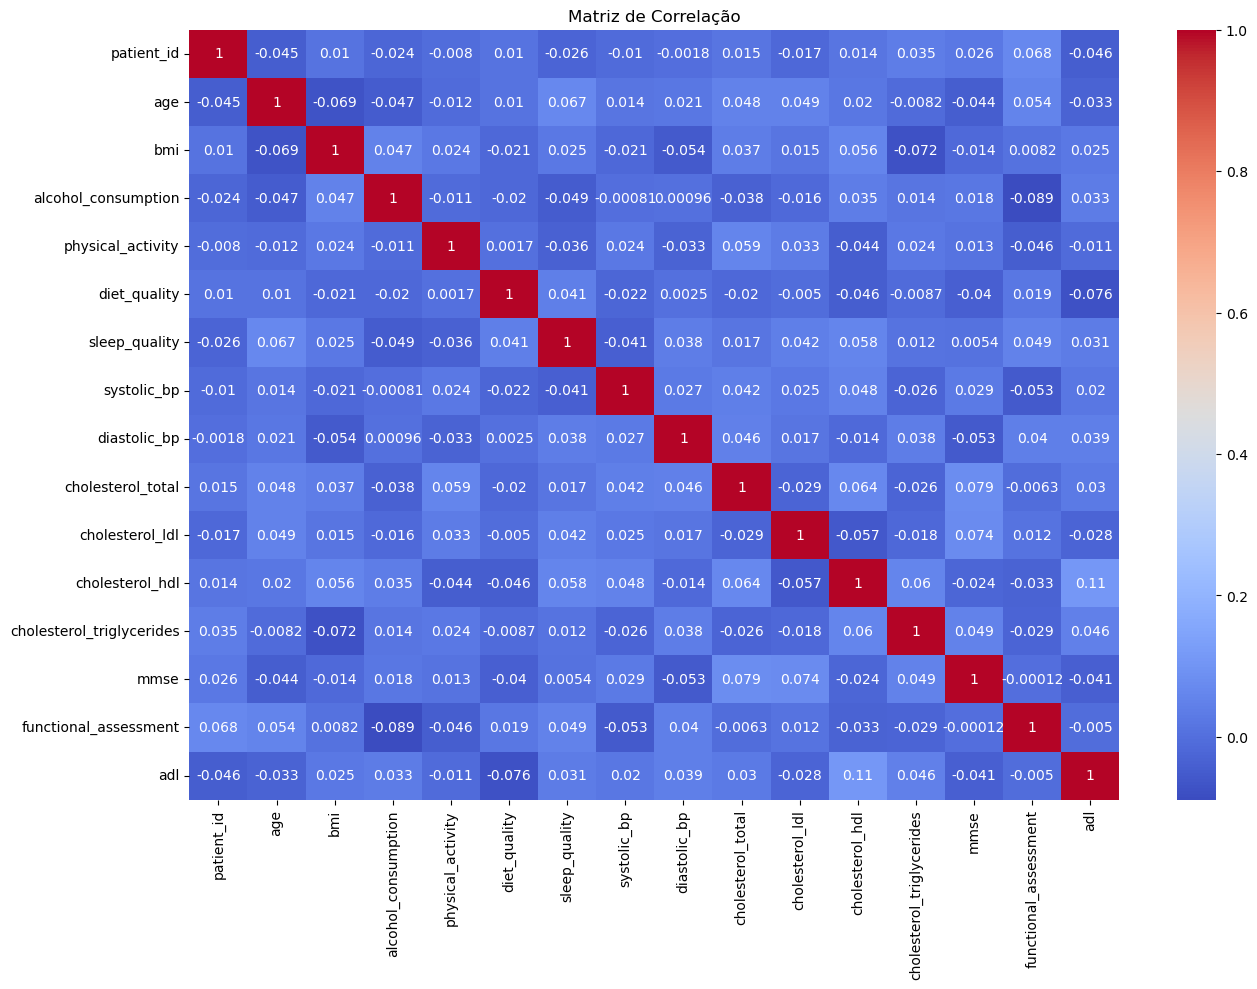

In [63]:
corr_matrix = df_num.corr()

# Visualização da matriz de correlação
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

## 5.3 Análise das distribuições

In [65]:
main_columns = ["age", "bmi", "systolic_bp", "cholesterol_total", "mmse", "adl"]

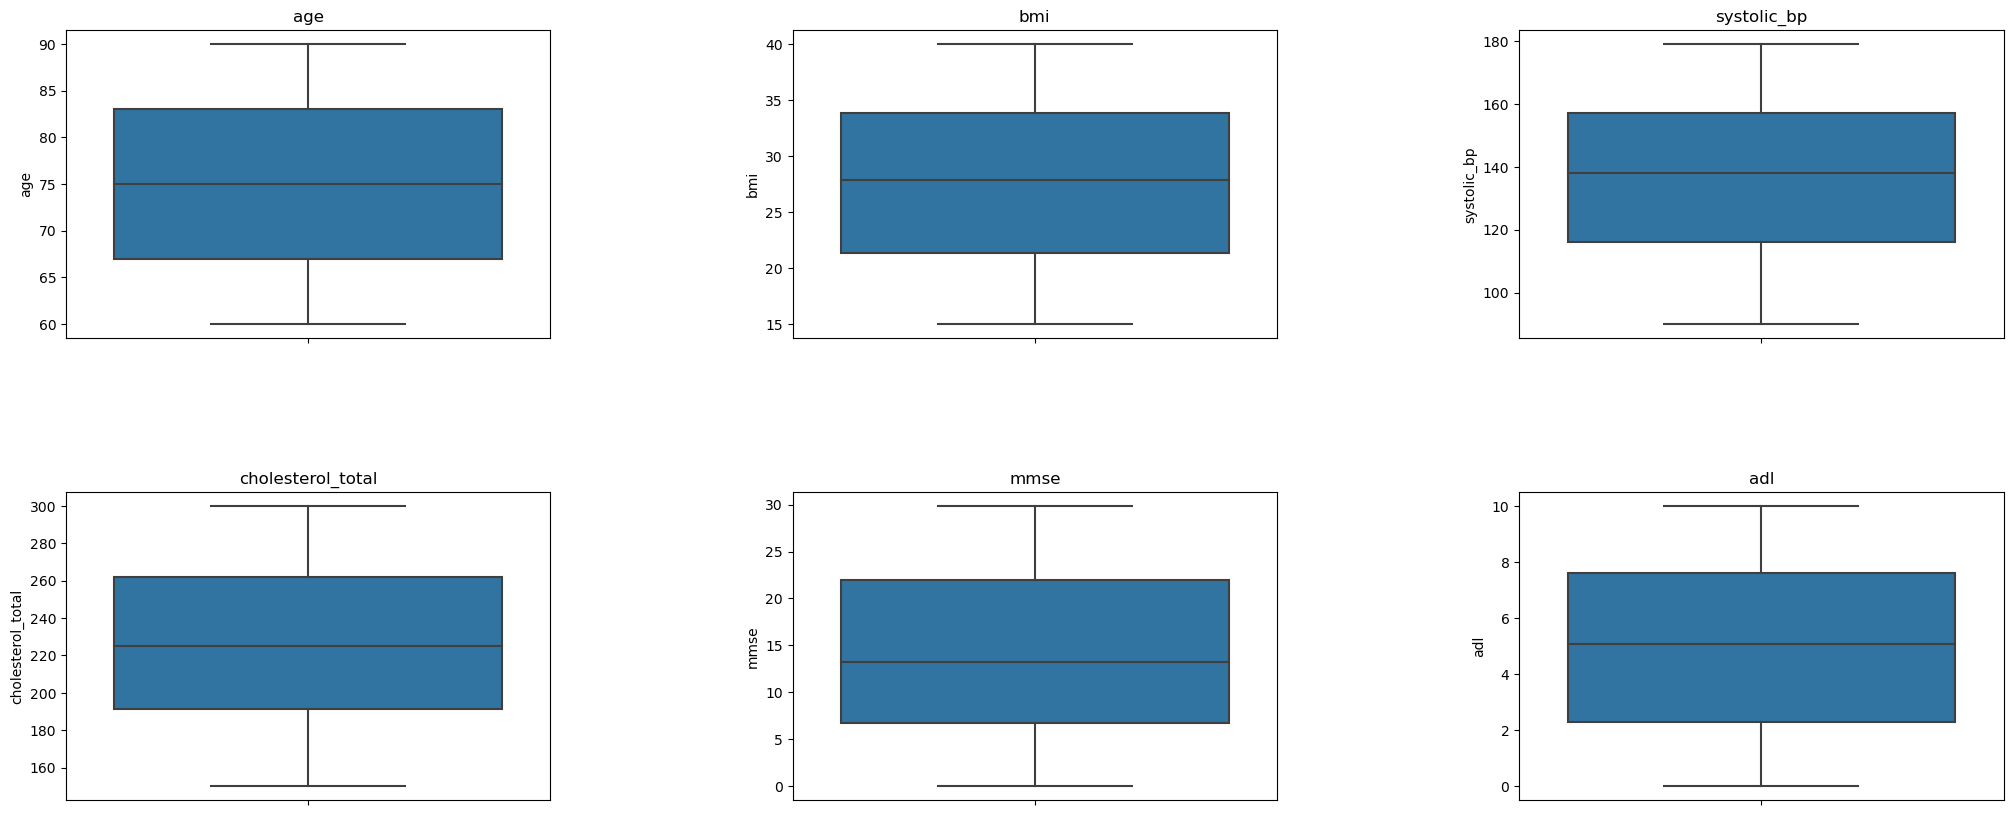

In [66]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.boxplot(df_num,y=str(col),ax=axes[i])
    axes[i].set_title(col)

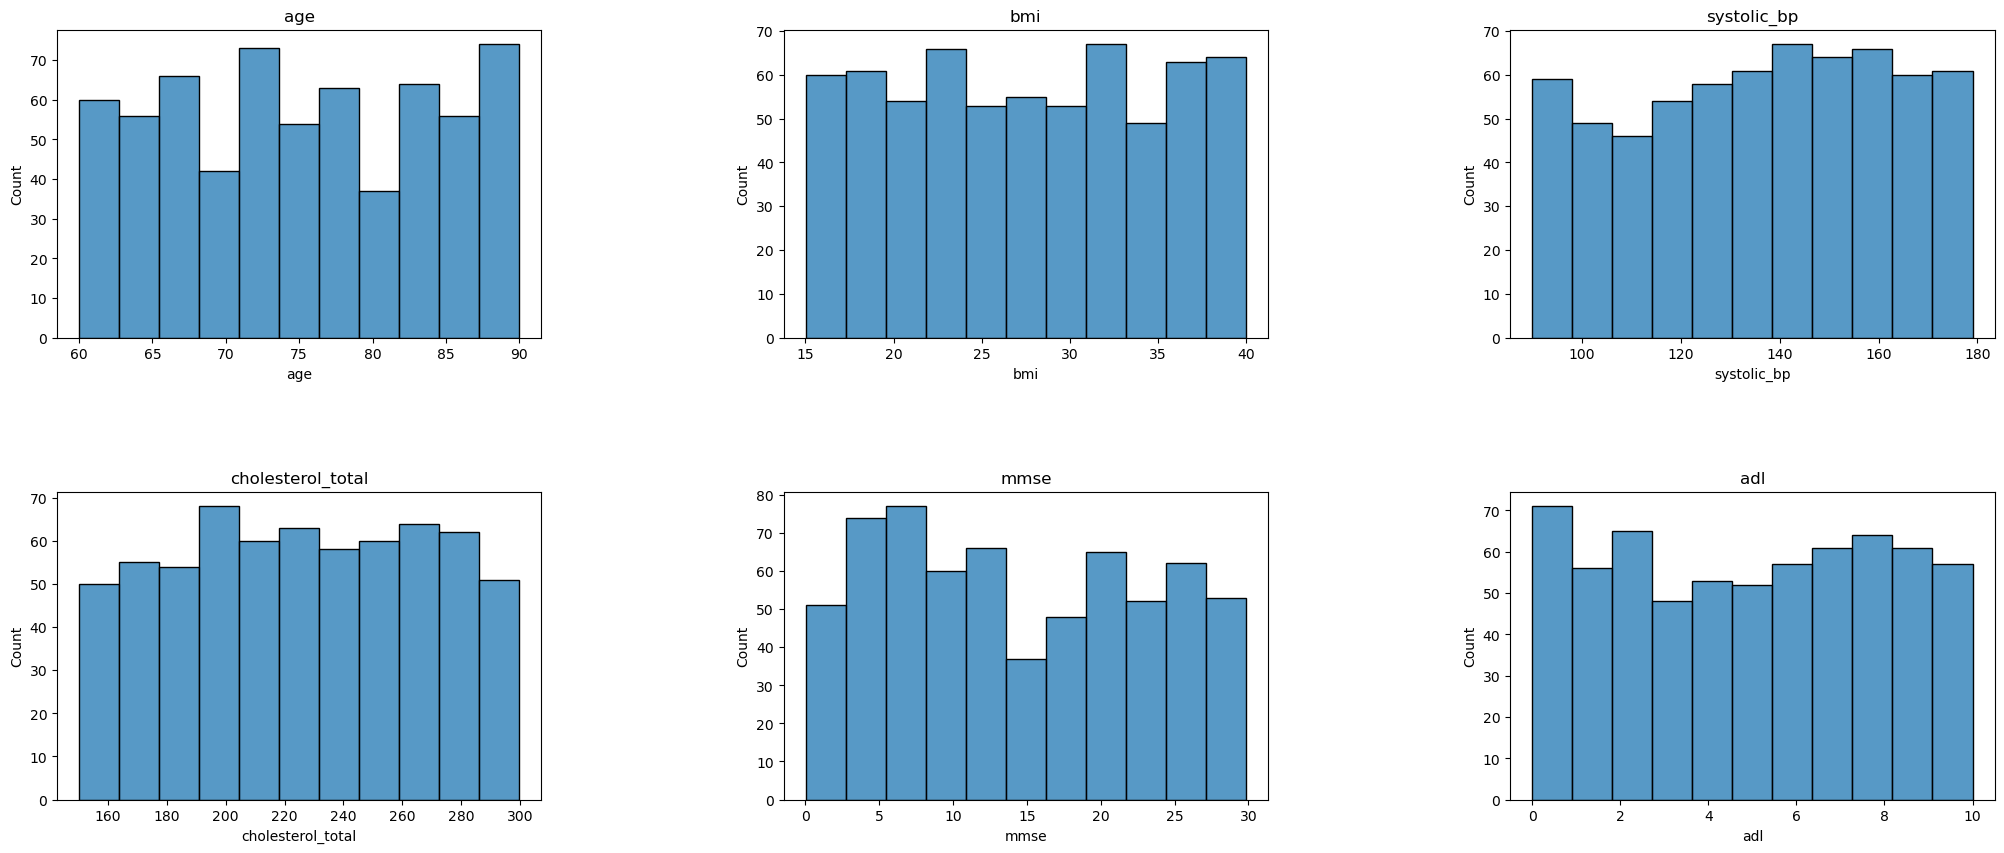

In [67]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.histplot(df_num,x=str(col),ax=axes[i])
    axes[i].set_title(col)

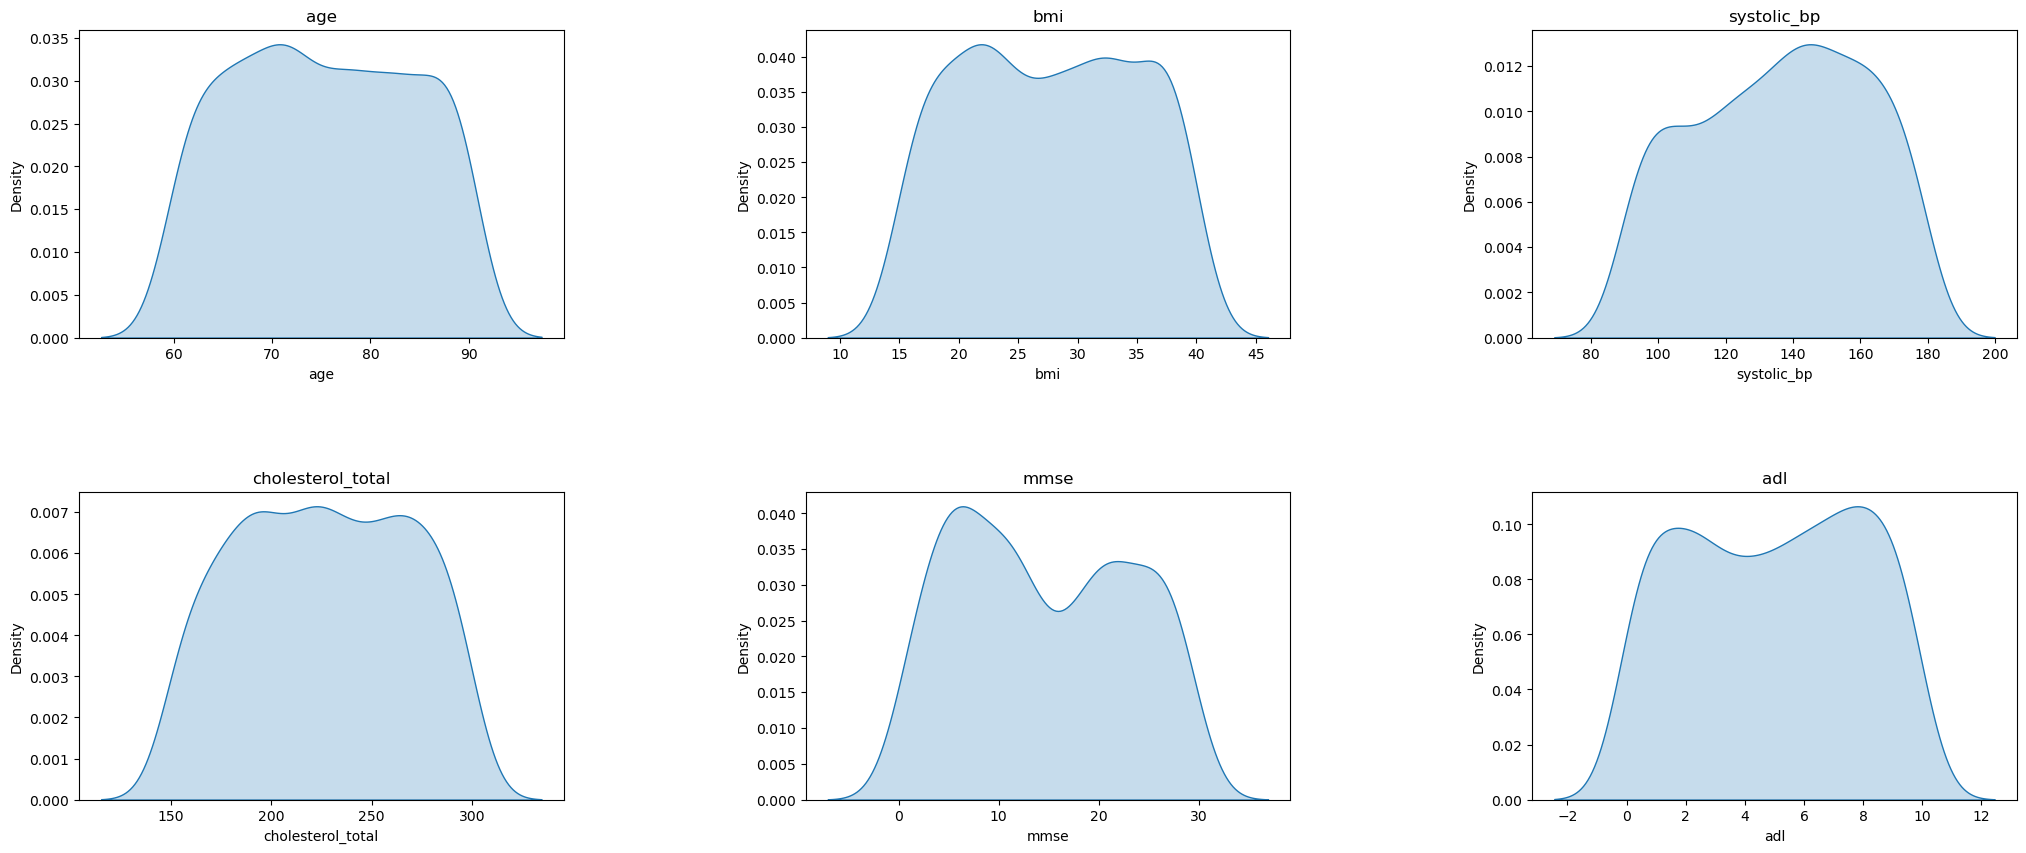

In [68]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.kdeplot(df_num,x=str(col),ax=axes[i], fill=True)
    axes[i].set_title(col)

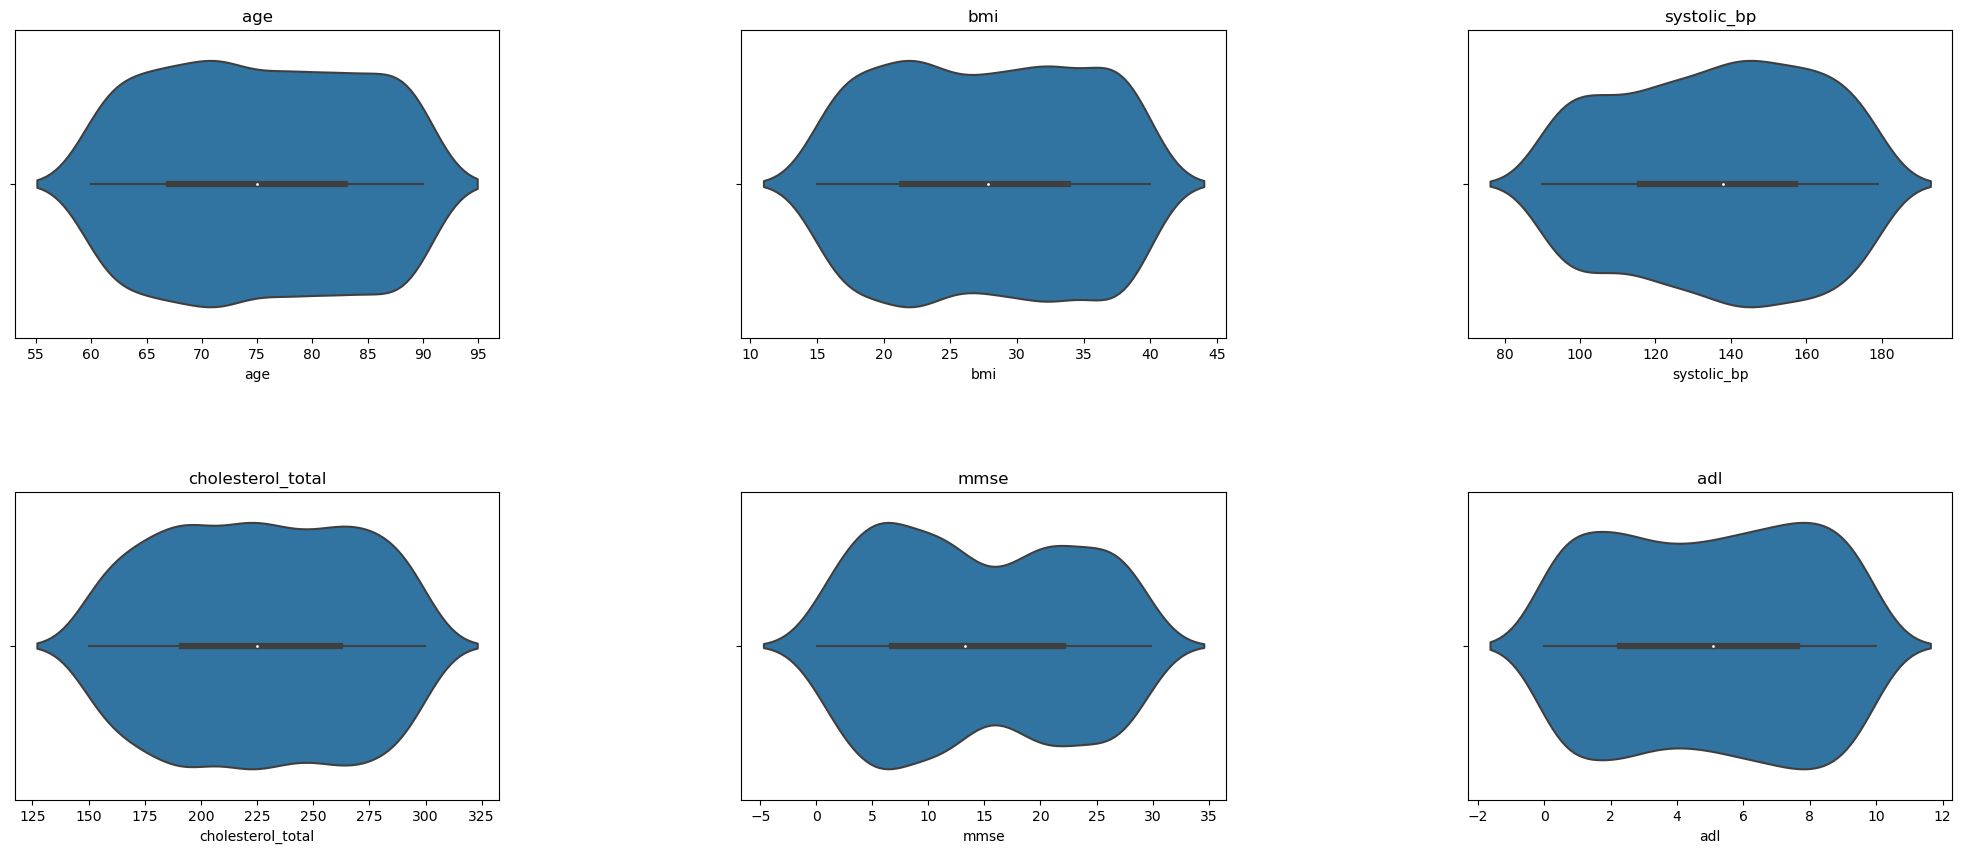

In [69]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.violinplot(df_num,x=str(col),ax=axes[i])
    axes[i].set_title(col)

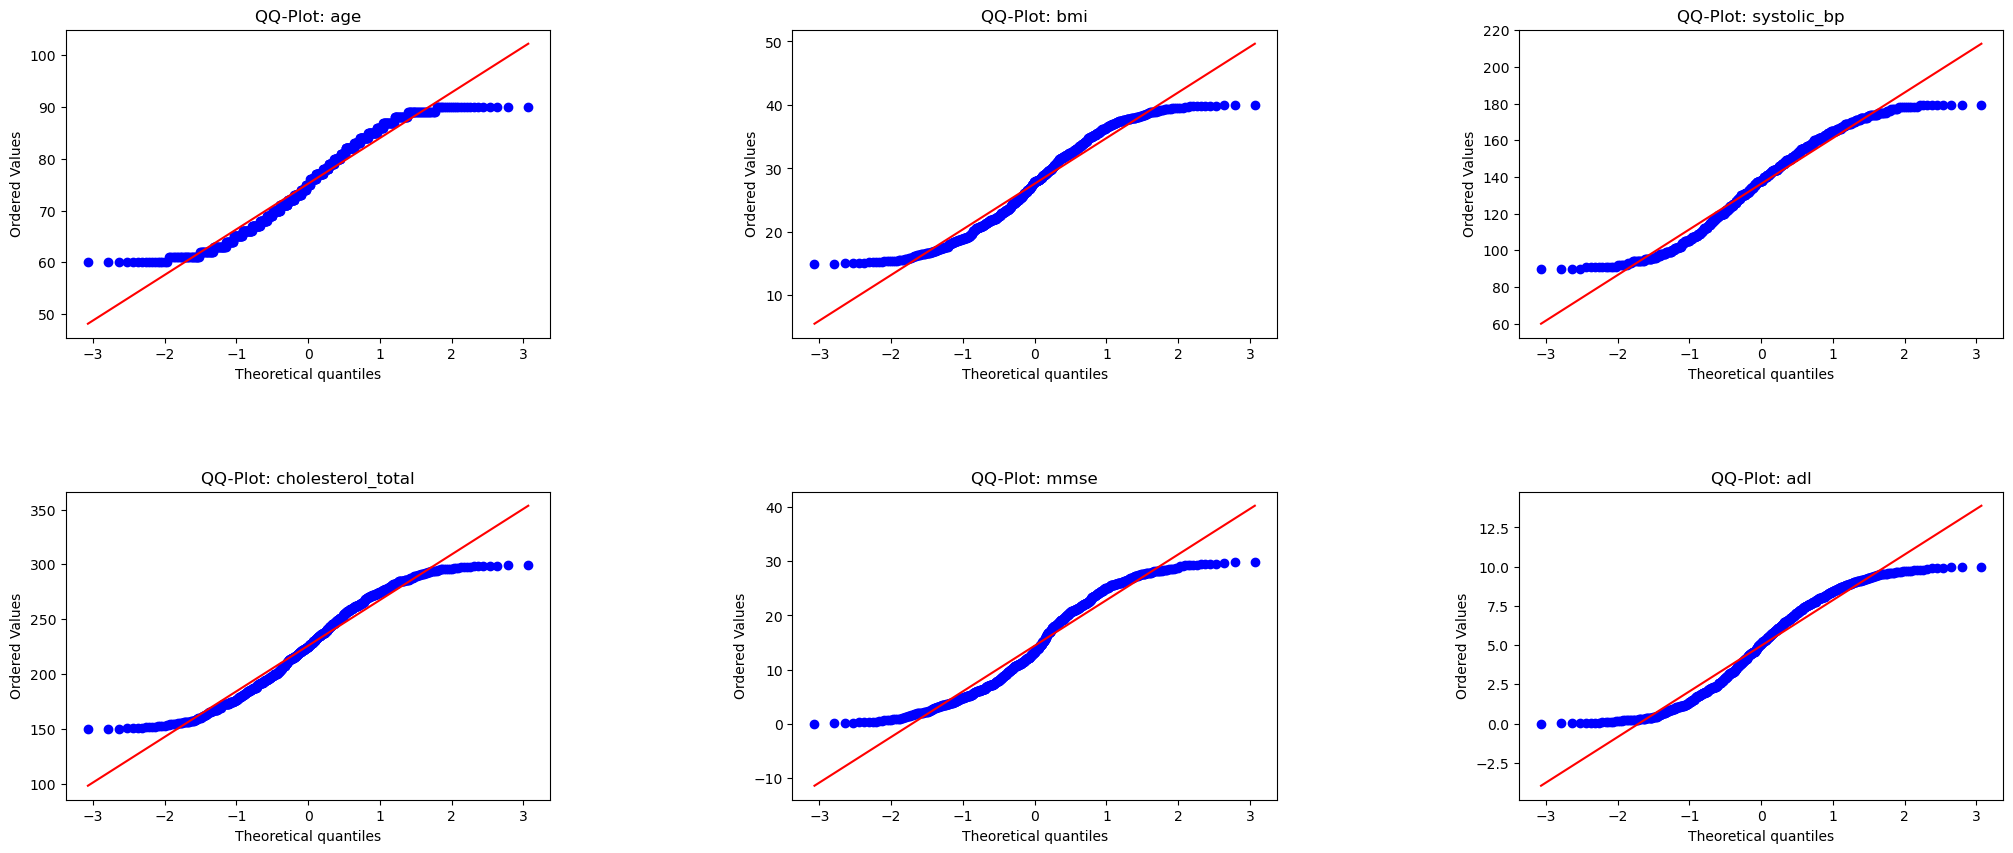

In [70]:
rows = (len(main_columns) + 1) // 3
columns = 3

fig, axes = plt.subplots(rows, columns, figsize=(25, 5 * rows))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.flatten()

for i, col in enumerate(main_columns):
    stats.probplot(df_num[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot: {col}')

plt.show()


# 6.0 Teste de hipótese das amostras

In [72]:
df6 = df5.copy()

## 6.1 Extraindo as amostras da base usando amostras aleatórias

In [74]:
am1 = df6.sample(frac=0.3, random_state=1)
am2 = df6.sample(frac=0.3, random_state = 45)

In [75]:
#colunas de estudo
main_columns = ["age", "bmi", "systolic_bp", "cholesterol_total", "mmse", "adl"]

## 6.2 Teste de normalidade das amostras

In [77]:
for linha in main_columns:
    stats1, p1 = stats.shapiro(am1[linha])
    stats2, p2 = stats.shapiro(am2[linha])

    print(f"Teste com a coluna: {linha}")
    
    alpha = 0.05
    if p1 > alpha:
        print("Amostra 1 parece seguir uma distribuição normal (não rejeita H0)")
    else:
        print("Amostra 1 não segue uma distribuição normal (rejeita H0)")
    
    if p2 > alpha:
        print("Amostra 2 parece seguir uma distribuição normal (não rejeita H0)")
    else:
        print("Amostra 2 não segue uma distribuição normal (rejeita H0)")

Teste com a coluna: age
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: bmi
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: systolic_bp
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: cholesterol_total
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: mmse
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: adl
Amostra 1 não segue uma distribuição normal (rejeita H0)
Amostra 2 não segue uma distribuição normal (rejeita H0)


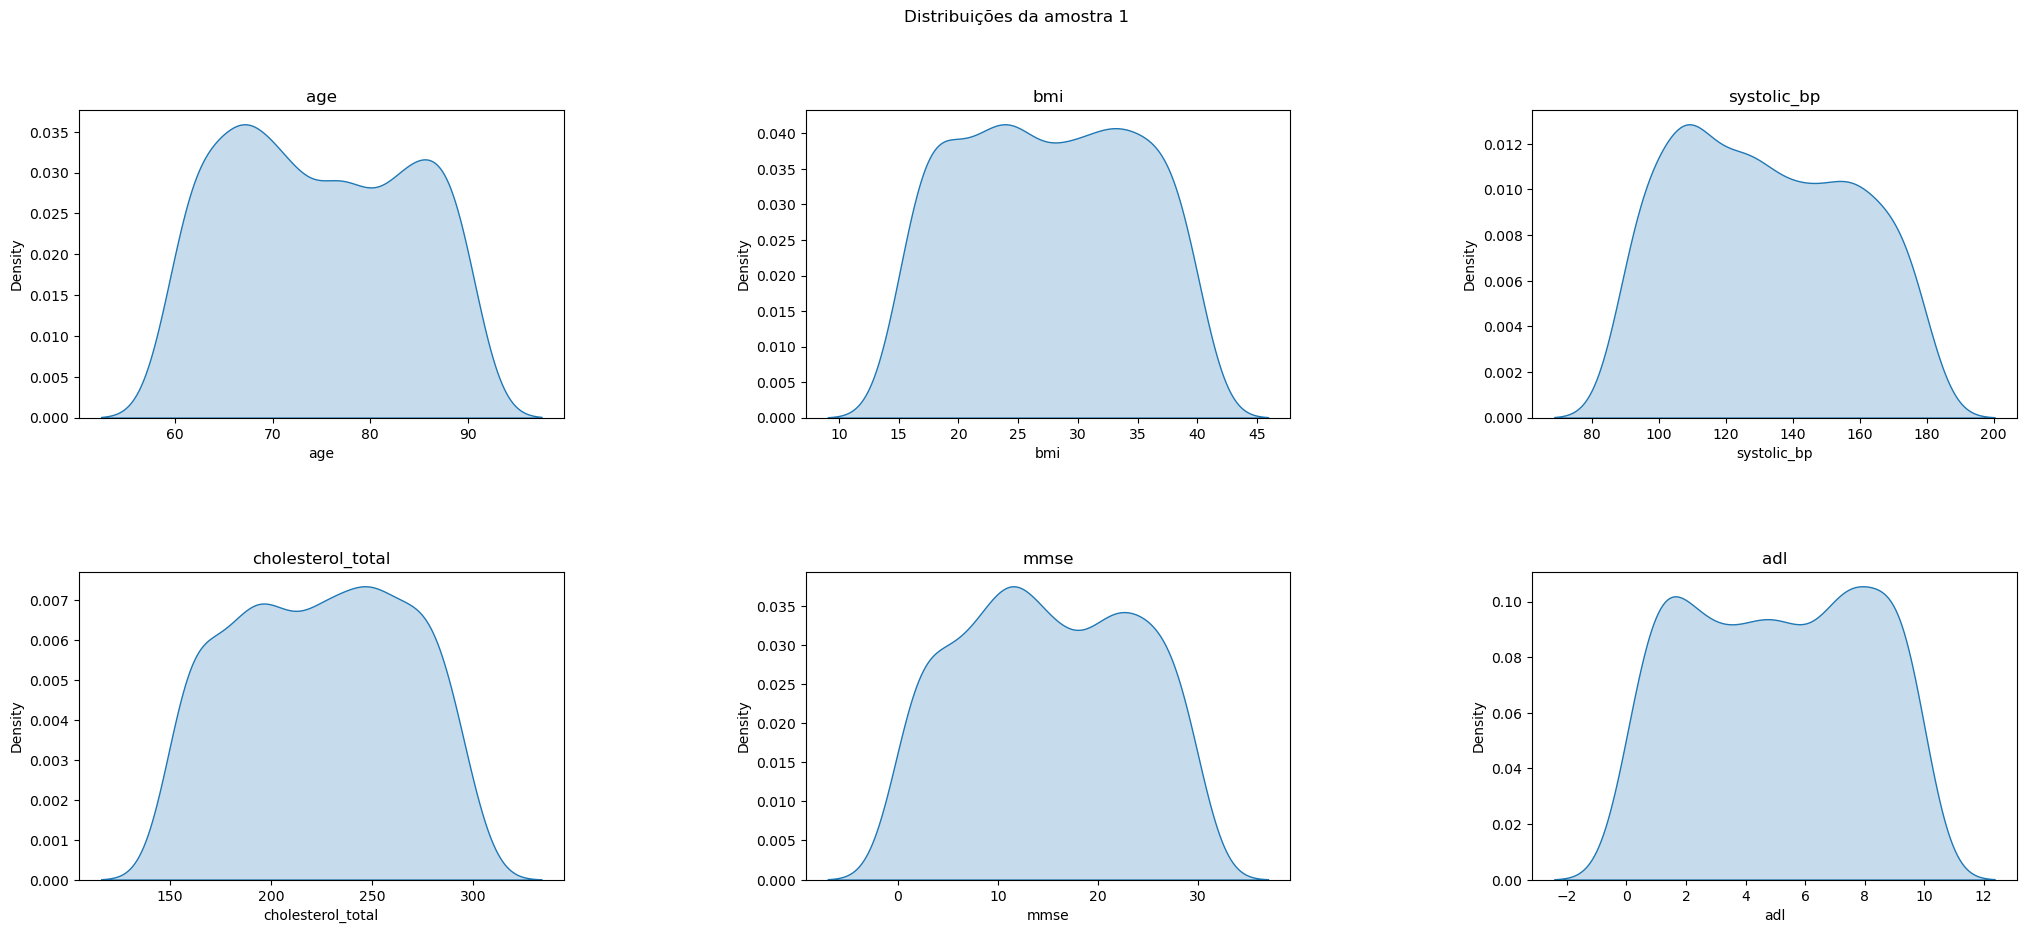

In [78]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
fig.suptitle("Distribuições da amostra 1")
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.kdeplot(am1,x=str(col),ax=axes[i], fill=True)
    axes[i].set_title(col)

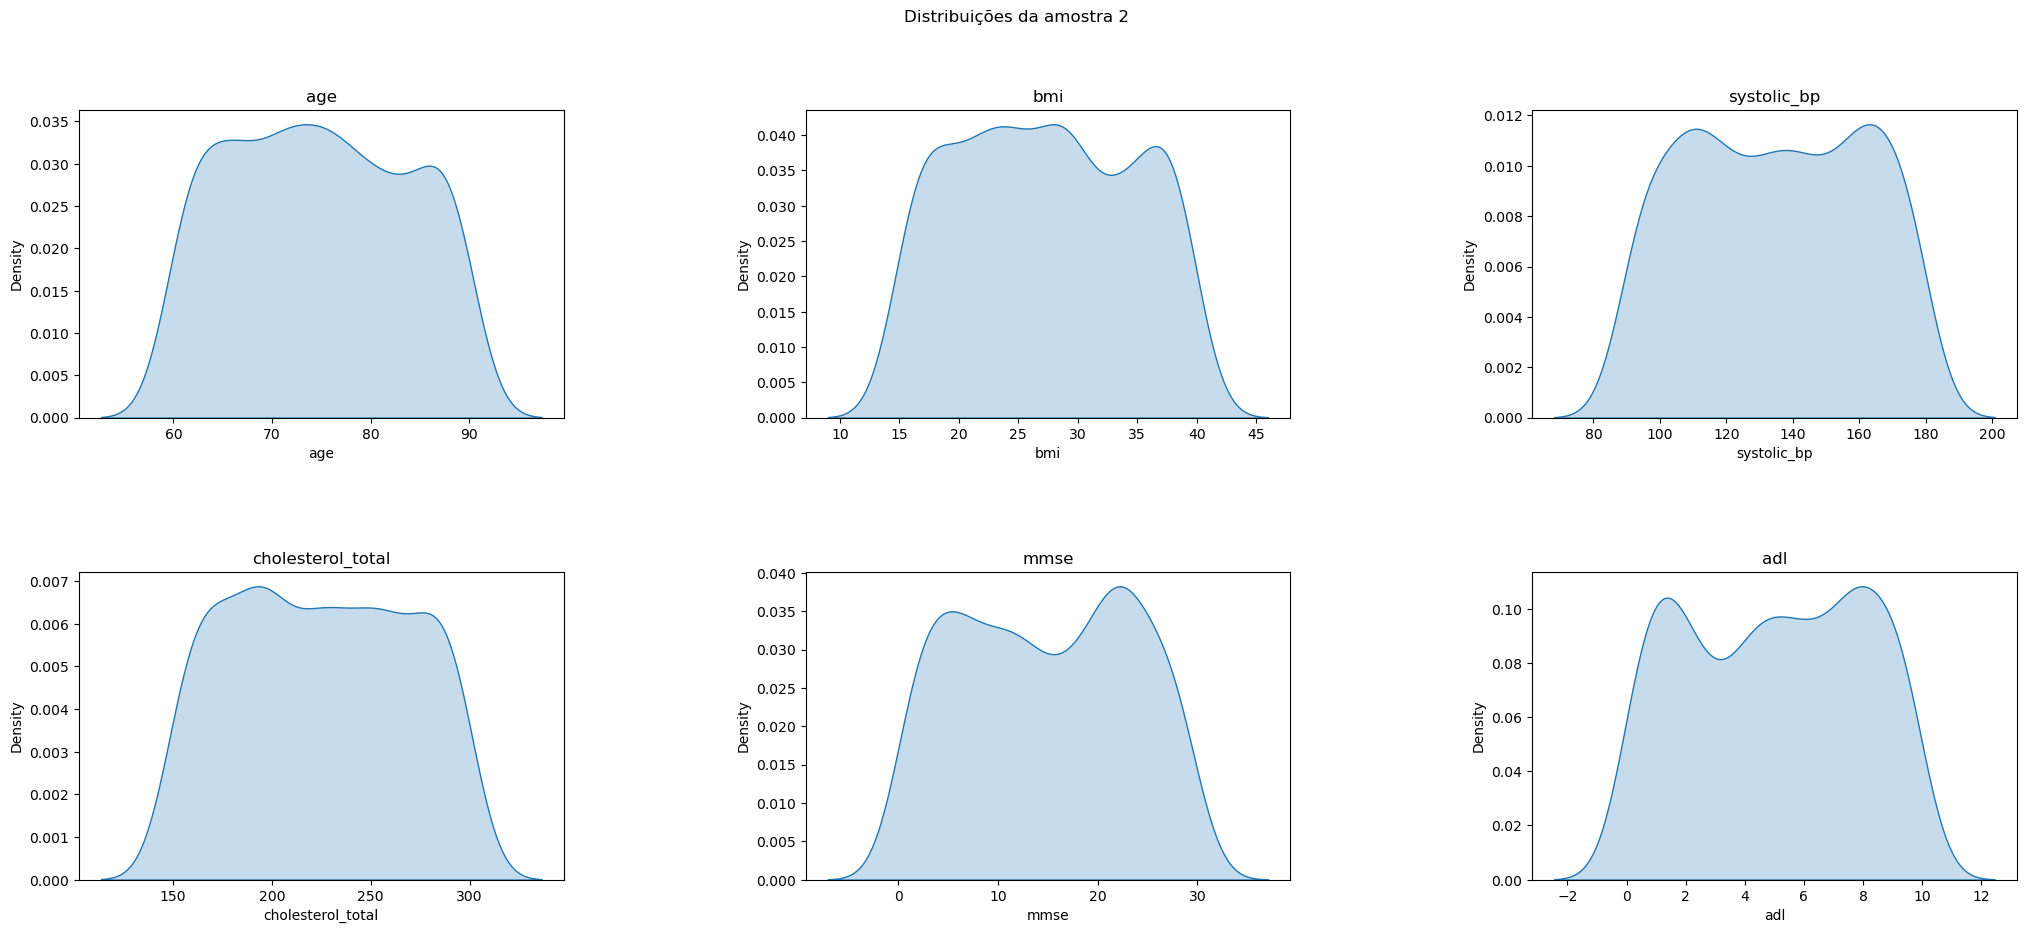

In [79]:
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
fig.suptitle("Distribuições da amostra 2")
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.kdeplot(am2,x=str(col),ax=axes[i], fill=True)
    axes[i].set_title(col)

## 6.3 Teste de correlação entre as bases

In [81]:
#Testes com a amostra 1
for i in range(len(main_columns)):
    j = i+1
    while(j < len(main_columns)):
        _, p = stats.pearsonr(am1[main_columns[i]], am1[main_columns[j]])
        alpha = 0.05
        if p > alpha:
            print(f"Da amostra 1 as colunas {main_columns[i]} e {main_columns[j]} provavelmente são independentes")
        else:
            print(f"Da amostra 1 as colunas {main_columns[i]} e {main_columns[j]} provavelmente são dependentes") 
        j+=1

Da amostra 1 as colunas age e bmi provavelmente são independentes
Da amostra 1 as colunas age e systolic_bp provavelmente são independentes
Da amostra 1 as colunas age e cholesterol_total provavelmente são independentes
Da amostra 1 as colunas age e mmse provavelmente são dependentes
Da amostra 1 as colunas age e adl provavelmente são independentes
Da amostra 1 as colunas bmi e systolic_bp provavelmente são independentes
Da amostra 1 as colunas bmi e cholesterol_total provavelmente são independentes
Da amostra 1 as colunas bmi e mmse provavelmente são dependentes
Da amostra 1 as colunas bmi e adl provavelmente são independentes
Da amostra 1 as colunas systolic_bp e cholesterol_total provavelmente são independentes
Da amostra 1 as colunas systolic_bp e mmse provavelmente são independentes
Da amostra 1 as colunas systolic_bp e adl provavelmente são independentes
Da amostra 1 as colunas cholesterol_total e mmse provavelmente são independentes
Da amostra 1 as colunas cholesterol_total e ad

In [82]:
#Testes com a amostra 2
for i in range(len(main_columns)):
    j = i+1
    while(j < len(main_columns)):
        _, p = stats.pearsonr(am2[main_columns[i]], am2[main_columns[j]])
        alpha = 0.05
        if p > alpha:
            print(f"Da amostra 2 as colunas {main_columns[i]} e {main_columns[j]} provavelmente são independentes")
        else:
            print(f"Da amostra 2 as colunas {main_columns[i]} e {main_columns[j]} provavelmente são dependentes") 
        j+=1

Da amostra 2 as colunas age e bmi provavelmente são independentes
Da amostra 2 as colunas age e systolic_bp provavelmente são independentes
Da amostra 2 as colunas age e cholesterol_total provavelmente são independentes
Da amostra 2 as colunas age e mmse provavelmente são independentes
Da amostra 2 as colunas age e adl provavelmente são dependentes
Da amostra 2 as colunas bmi e systolic_bp provavelmente são independentes
Da amostra 2 as colunas bmi e cholesterol_total provavelmente são independentes
Da amostra 2 as colunas bmi e mmse provavelmente são independentes
Da amostra 2 as colunas bmi e adl provavelmente são independentes
Da amostra 2 as colunas systolic_bp e cholesterol_total provavelmente são independentes
Da amostra 2 as colunas systolic_bp e mmse provavelmente são independentes
Da amostra 2 as colunas systolic_bp e adl provavelmente são independentes
Da amostra 2 as colunas cholesterol_total e mmse provavelmente são independentes
Da amostra 2 as colunas cholesterol_total e 

## 6.4 Análise de distribuição

In [84]:
for linha in main_columns:

    stat, p = stats.kruskal(am1[linha], am2[linha])

    print(f"Teste com a coluna: {linha}")
    
    alpha = 0.05
    if p > alpha:
        print("As amostras provavelmente tem a mesma distribuição (não rejeita H0)")
    else:
        print("As amostras provavelmente não tem a mesma distribuição (rejeita H0)")
#TODO: gráficos de visualização

Teste com a coluna: age
As amostras provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: bmi
As amostras provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: systolic_bp
As amostras provavelmente não tem a mesma distribuição (rejeita H0)
Teste com a coluna: cholesterol_total
As amostras provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: mmse
As amostras provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: adl
As amostras provavelmente tem a mesma distribuição (não rejeita H0)


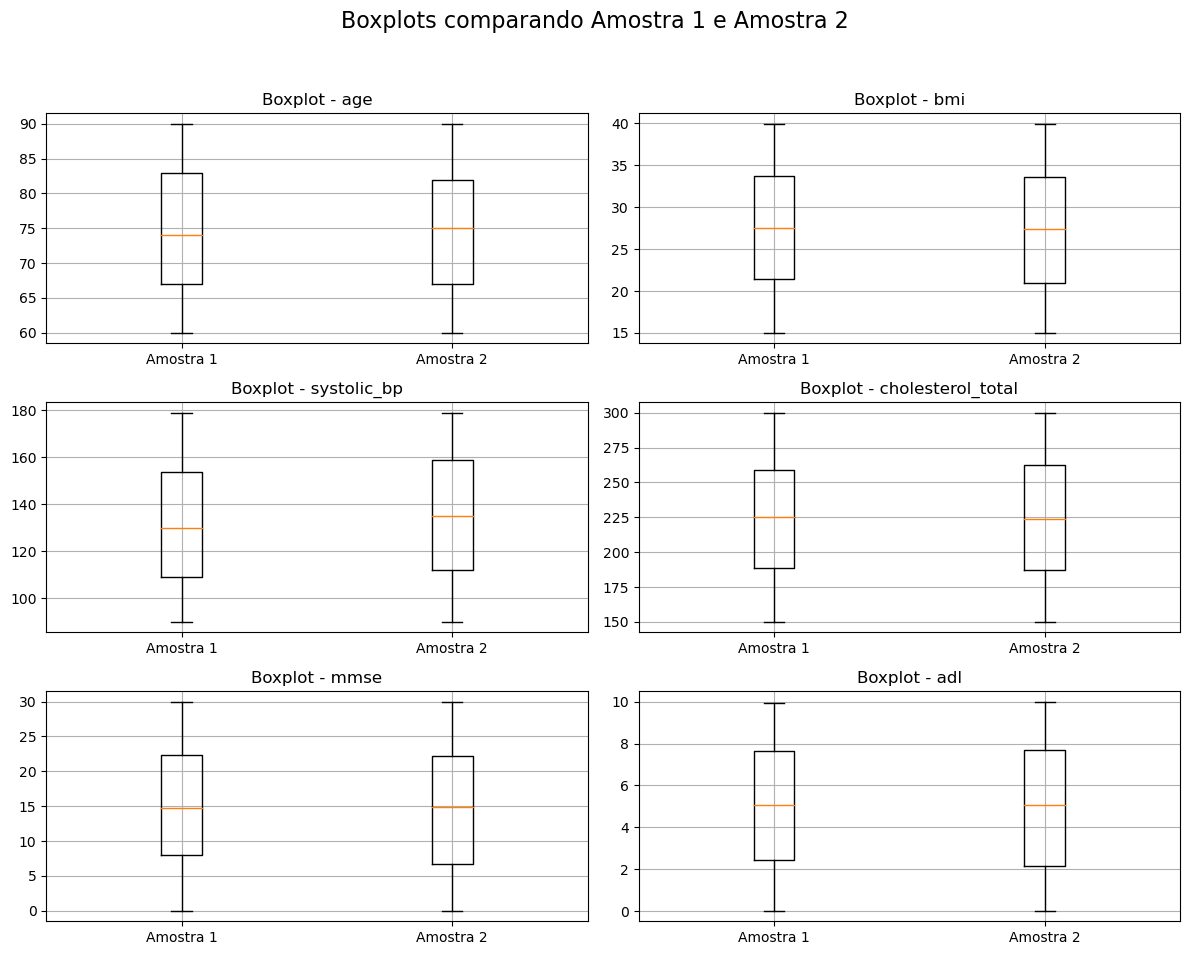

In [85]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.suptitle('Boxplots comparando Amostra 1 e Amostra 2', fontsize=16)

axes = axes.flatten()

for i, coluna in enumerate(main_columns):
    axes[i].boxplot([am1[coluna], am2[coluna]], labels=["Amostra 1", "Amostra 2"])
    axes[i].set_title(f'Boxplot - {coluna}')
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# 7.0 Simulação dos testes de hipótese

In [87]:
df7 = df6.copy()

In [88]:
df_analise, df_validacao = train_test_split(df7, test_size = 0.3, random_state = 10)

In [89]:
amostras = [df_analise.sample(frac=0.3, random_state = x) for x in range (3)]

## 7.1 Teste de Kruskal

In [91]:
for x in range(3):
    y = (x+1) % 3
    for linha in main_columns:
    
        stat, p = stats.kruskal(amostras[x][linha], amostras[y][linha])
    
        print(f"Teste com a coluna: {linha}")
        
        alpha = 0.05
        if p > alpha:
            print(f"A coluna {linha} das amostras {x} e {y} provavelmente tem a mesma distribuição (não rejeita H0)")
        else:
            print(f"A coluna {linha} das amostras {x} e {y} provavelmente não tem a mesma distribuição (rejeita H0)")
    print("="*50)

Teste com a coluna: age
A coluna age das amostras 0 e 1 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: bmi
A coluna bmi das amostras 0 e 1 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: systolic_bp
A coluna systolic_bp das amostras 0 e 1 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: cholesterol_total
A coluna cholesterol_total das amostras 0 e 1 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: mmse
A coluna mmse das amostras 0 e 1 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: adl
A coluna adl das amostras 0 e 1 provavelmente não tem a mesma distribuição (rejeita H0)
Teste com a coluna: age
A coluna age das amostras 1 e 2 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: bmi
A coluna bmi das amostras 1 e 2 provavelmente tem a mesma distribuição (não rejeita H0)
Teste com a coluna: systolic_bp
A coluna systolic_bp das a

## 7.2 Teste de Shapiro

In [93]:
for x in range(3):
    for linha in main_columns:
        stats1, p1 = stats.shapiro(amostras[x][linha])
    
        print(f"Teste com a coluna: {linha}")
        
        alpha = 0.05
        if p1 > alpha:
            print(f"A coluna {linha} da amostra parece seguir uma distribuição normal (não rejeita H0)")
        else:
            print(f"A coluna {linha}da amostra 1 não segue uma distribuição normal (rejeita H0)")
    print("="*50)

Teste com a coluna: age
A coluna ageda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: bmi
A coluna bmida amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: systolic_bp
A coluna systolic_bpda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: cholesterol_total
A coluna cholesterol_totalda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: mmse
A coluna mmseda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: adl
A coluna adlda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: age
A coluna ageda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: bmi
A coluna bmida amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: systolic_bp
A coluna systolic_bpda amostra 1 não segue uma distribuição normal (rejeita H0)
Teste com a coluna: cholesterol_total
A coluna cholesterol_totalda amostra

## 7.3 Teste de correlação

In [95]:
for x in range(3):
    for i in range(len(main_columns)):
        j = i+1
        while(j < len(main_columns)):
            _, p = stats.pearsonr(amostras[x][main_columns[i]], amostras[x][main_columns[j]])
            alpha = 0.05
            if p > alpha:
                print(f"Da amostra {x} as colunas {main_columns[i]} e {main_columns[j]} provavelmente são independentes")
            else:
                print(f"Da amostra {x} as colunas {main_columns[i]} e {main_columns[j]} provavelmente são dependentes") 
            j+=1
            
    print("="*50)

Da amostra 0 as colunas age e bmi provavelmente são independentes
Da amostra 0 as colunas age e systolic_bp provavelmente são independentes
Da amostra 0 as colunas age e cholesterol_total provavelmente são independentes
Da amostra 0 as colunas age e mmse provavelmente são independentes
Da amostra 0 as colunas age e adl provavelmente são independentes
Da amostra 0 as colunas bmi e systolic_bp provavelmente são independentes
Da amostra 0 as colunas bmi e cholesterol_total provavelmente são independentes
Da amostra 0 as colunas bmi e mmse provavelmente são independentes
Da amostra 0 as colunas bmi e adl provavelmente são independentes
Da amostra 0 as colunas systolic_bp e cholesterol_total provavelmente são independentes
Da amostra 0 as colunas systolic_bp e mmse provavelmente são independentes
Da amostra 0 as colunas systolic_bp e adl provavelmente são independentes
Da amostra 0 as colunas cholesterol_total e mmse provavelmente são independentes
Da amostra 0 as colunas cholesterol_total 

## 7.4 Loop de simulação

In [97]:
os.makedirs("midia/simulacoes/boxplots", exist_ok=True)
os.makedirs("midia/simulacoes/qqplots", exist_ok=True)
os.makedirs("midia/simulacoes/densidade", exist_ok=True)

In [98]:
alpha = 0.05

potencias = []

resultados_metricas = []

with open("simulacao.txt", "w", encoding="utf-8") as log:
    for sim in range(30):
        titulo = f"\n{'='*20} Simulação {sim+1} {'='*20}\n"
        print(titulo)
        log.write(titulo)

        df_analise, df_validacao = train_test_split(df7, test_size=0.3)
        amostras = [df_analise.sample(frac=0.3) for _ in range(3)]

        for col in main_columns:
            
            # Teste de Shapiro
            for idx, amostra in enumerate(amostras):
                resultado = teste_shapiro(amostra[col], alpha)
                msg = f"Na amostra {idx + 1} a coluna {col} " + (
                    "indica uma distribuição normal" if resultado else
                    "não dá possibilidade de indicar uma distribuição normal"
                )
                print(msg)
                log.write(msg + "\n")

            # Teste de Kruskal entre amostras
            combinacoes = [(0, 1), (0, 2), (1, 2)]
            for idx1, idx2 in combinacoes:
                resultado = teste_kruskal(amostras[idx1][col], amostras[idx2][col], alpha)
                msg = f"Nas amostras {idx1+1} e {idx2+1} a coluna {col} " + (
                    "tem a mesma distribuição" if resultado else
                    "não tem a mesma distribuição"
                )
                print(msg)
                log.write(msg + "\n")

            # Teste de Pearson nas amostras
            for idx, amostra in enumerate(amostras):
                resultado_pearson = teste_pearson(amostra, col, main_columns, alpha)
                descrever_dependencia_pearson(resultado_pearson, col, main_columns, f"amostra {idx+1}", log)

            # Validação
            # Shapiro
            resultado = teste_shapiro(df_validacao[col], alpha)
            msg = f"Na base de validação a coluna {col} " + (
                "indica uma distribuição normal" if resultado else
                "não dá possibilidade de indicar uma distribuição normal"
            )
            print(msg)
            log.write(msg + "\n")

            # Kruskal com amostras
            for idx, amostra in enumerate(amostras):
                resultado = teste_kruskal(df_validacao[col], amostra[col], alpha)
                msg = f"Entre a base de validação e a amostra {idx+1} a coluna {col} " + (
                    "tem a mesma distribuição" if resultado else
                    "não tem a mesma distribuição"
                )
                print(msg)
                log.write(msg + "\n")

            # Pearson com base de validação
            resultado_pearson_val = teste_pearson(df_validacao, col, main_columns, alpha)
            descrever_dependencia_pearson(resultado_pearson_val, col, main_columns, "base de validação", log)

            separador = "-" * 50 + "\n"
            print(separador)
            log.write(separador)

        salvar_densidade(main_columns, amostras, df_validacao, sim)
        salvar_boxplot(main_columns, amostras, df_validacao, sim)
        salvar_qqqplot(main_columns, amostras, df_validacao, sim)

        fim_simulacao = "=" * 50 + "\n"
        
        print(fim_simulacao)
        log.write(fim_simulacao)



==================== Simulação 1 ====================

Na amostra 1 a coluna age não dá possibilidade de indicar uma distribuição normal
Na amostra 2 a coluna age não dá possibilidade de indicar uma distribuição normal
Na amostra 3 a coluna age não dá possibilidade de indicar uma distribuição normal
Nas amostras 1 e 2 a coluna age tem a mesma distribuição
Nas amostras 1 e 3 a coluna age tem a mesma distribuição
Nas amostras 2 e 3 a coluna age tem a mesma distribuição
Na amostra 1 as colunas age e bmi são dependentes
Na amostra 1 as colunas age e systolic_bp são dependentes
Na amostra 1 as colunas age e cholesterol_total são dependentes
Na amostra 1 as colunas age e mmse são dependentes
Na amostra 1 as colunas age e adl são dependentes
Na amostra 2 as colunas age e bmi são dependentes
Na amostra 2 as colunas age e systolic_bp são dependentes
Na amostra 2 as colunas age e cholesterol_total são dependentes
Na amostra 2 as colunas age e mmse são dependentes
Na amostra 2 as colunas age e a

## 7.5 Resultados Simulações

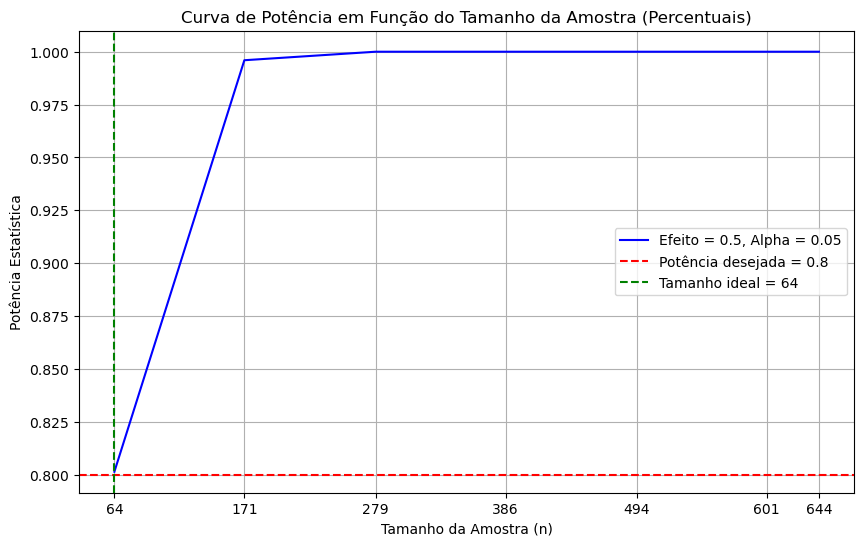

In [100]:
effect_size = 0.5  # Tamanho do efeito
alpha = 0.05       # Nível de significância
power_target = 0.8 # Potência desejada
n_total = len(df7) # <-- substitua df7 pelo seu DataFrame

# Percentuais desejados
percentuais = [3, 8, 13, 18, 23, 28, 30]
sample_sizes = [int(n_total * (p / 100)) for p in percentuais]

# Calculando a potência para cada tamanho de amostra
analysis = TTestIndPower()
powers = [analysis.solve_power(effect_size=effect_size, nobs1=n, alpha=alpha, power=None, alternative='two-sided') for n in sample_sizes]

# Encontrar o tamanho ideal se existir
powers_array = np.array(powers)
n_ideal = None
for i, pwr in enumerate(powers):
    if pwr >= power_target:
        n_ideal = sample_sizes[i]
        break

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, powers, color='blue', label=f'Efeito = {effect_size}, Alpha = {alpha}')
plt.axhline(y=power_target, color='red', linestyle='--', label=f'Potência desejada = {power_target}')
if n_ideal:
    plt.axvline(x=n_ideal, color='green', linestyle='--', label=f'Tamanho ideal = {n_ideal}')

plt.title('Curva de Potência em Função do Tamanho da Amostra (Percentuais)')
plt.xlabel('Tamanho da Amostra (n)')
plt.ylabel('Potência Estatística')
plt.xticks(sample_sizes)
plt.grid(True)
plt.legend()
plt.show()


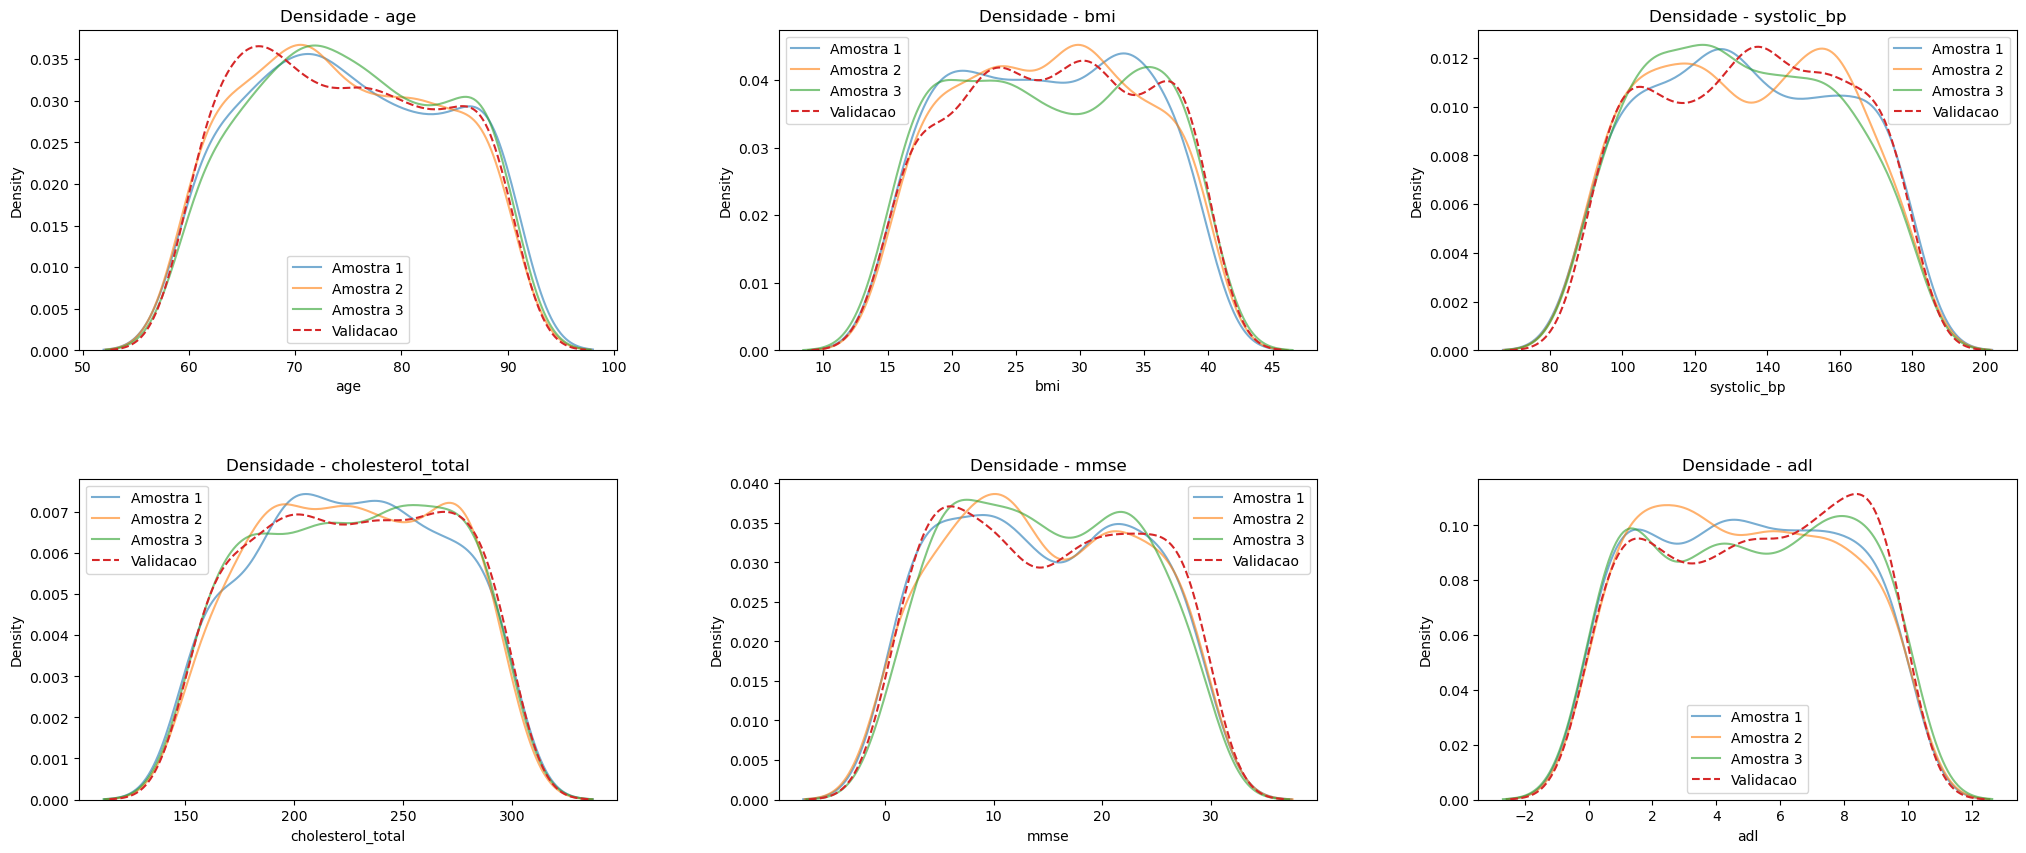

In [101]:
rows = (len(main_columns) + 1) // 3
columns = 3

fig, axes = plt.subplots(rows, columns, figsize=(25, 5 * rows))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
axes = axes.flatten()

for i, col in enumerate(main_columns):
    for j, amostra in enumerate(amostras):
        sns.kdeplot(amostra[col], label=f"Amostra {j+1}", alpha=0.6, ax=axes[i])
    sns.kdeplot(df_validacao[col], label='Validacao', linestyle='--', ax=axes[i])
    axes[i].set_title(f'Densidade - {col}')
    axes[i].legend()

# Remove eixos extras, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

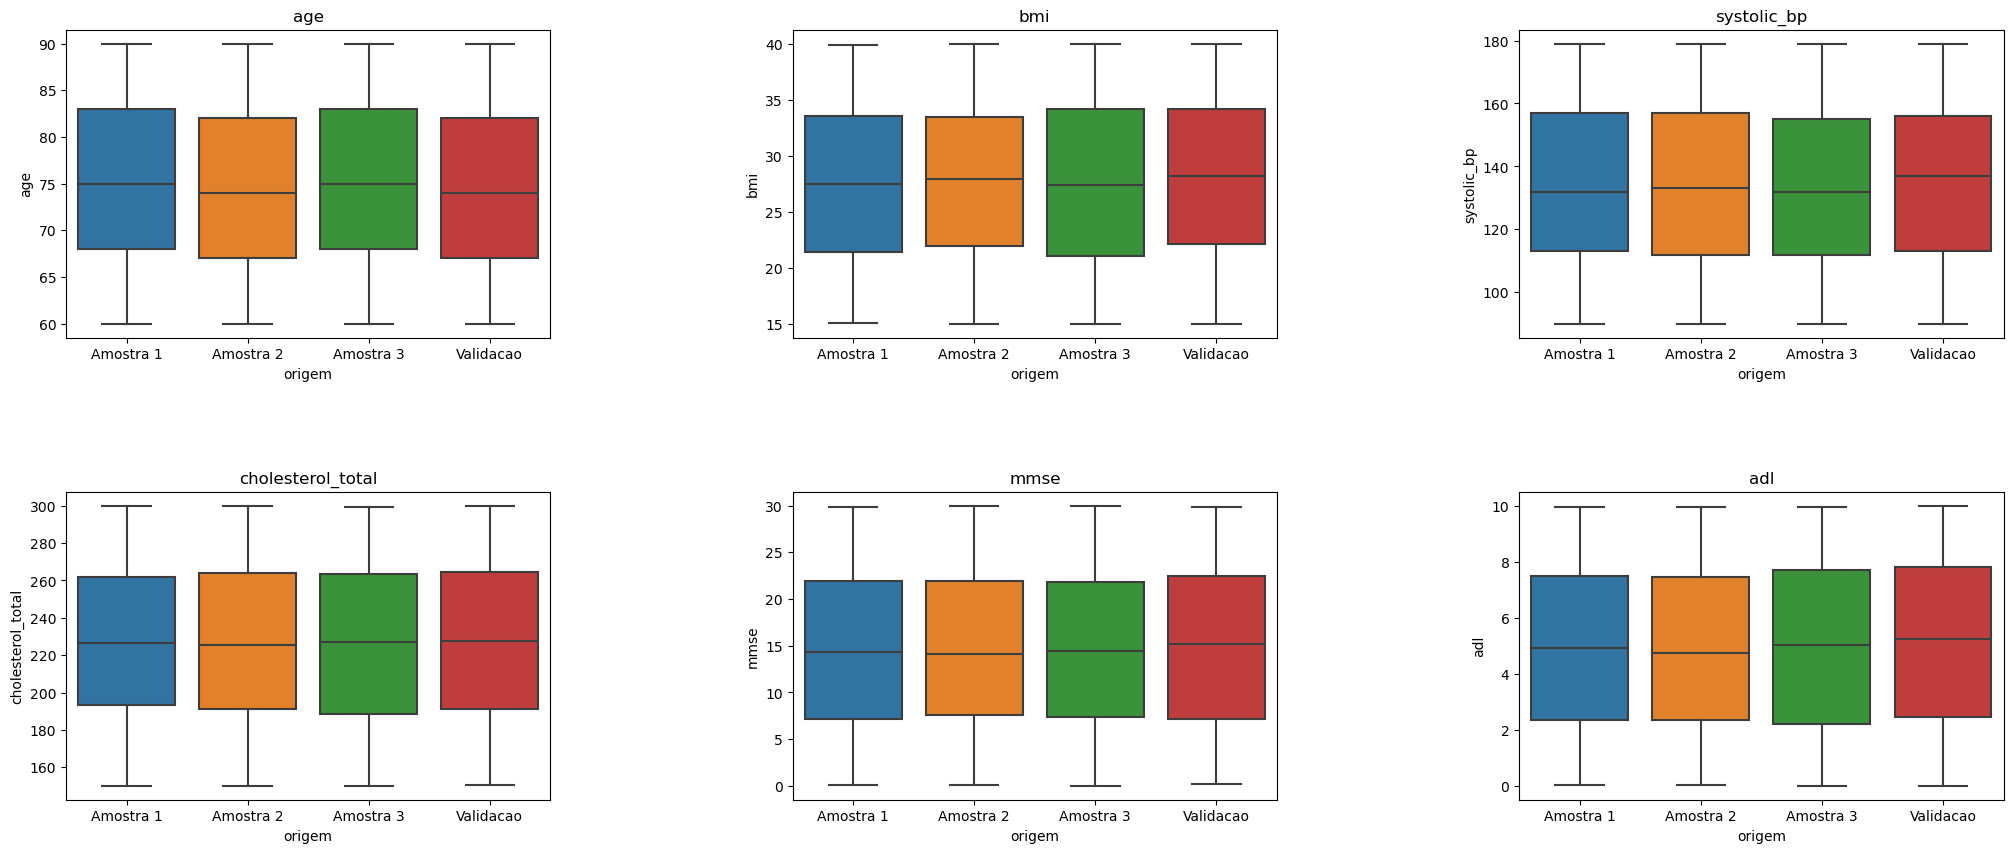

In [102]:
# Boxplot comparativo
dados_box = pd.concat([
    amostras[0].assign(origem='Amostra 1'),
    amostras[1].assign(origem='Amostra 2'),
    amostras[2].assign(origem='Amostra 3'),
    df_validacao.assign(origem='Validacao')
])
rows = (len(main_columns) + 1 )//3

columns = 3

fig,axes = plt.subplots(rows,columns,figsize=(25,5*rows))
plt.subplots_adjust(wspace=0.5,hspace=0.5)
axes = axes.flatten()

for i,col in enumerate(main_columns):
    sns.boxplot(data=dados_box, x='origem', y=col, ax=axes[i])
    axes[i].set_title(col)

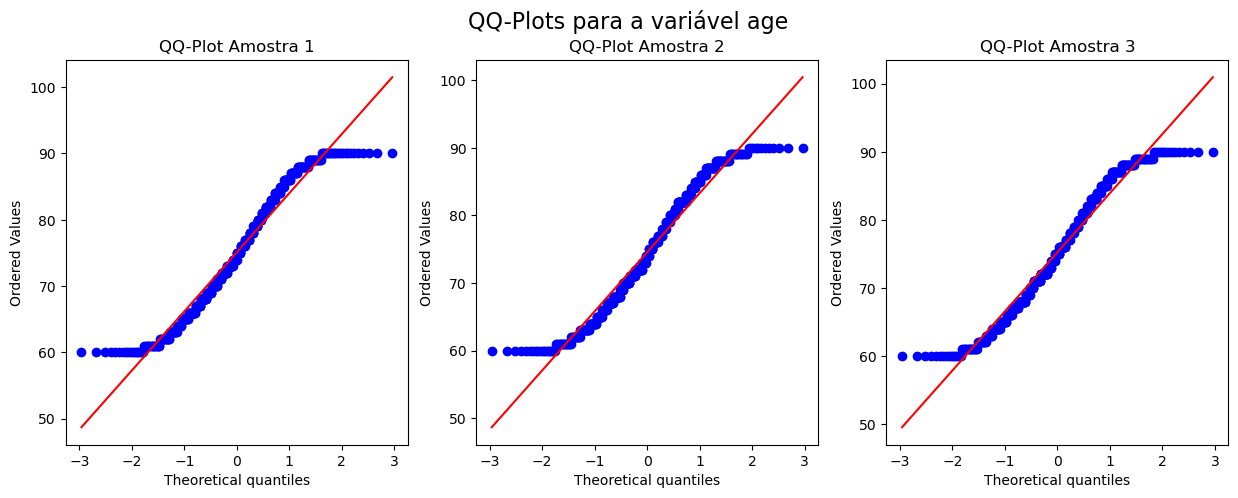

In [103]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[0]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[0]}", fontsize=16)
plt.show()

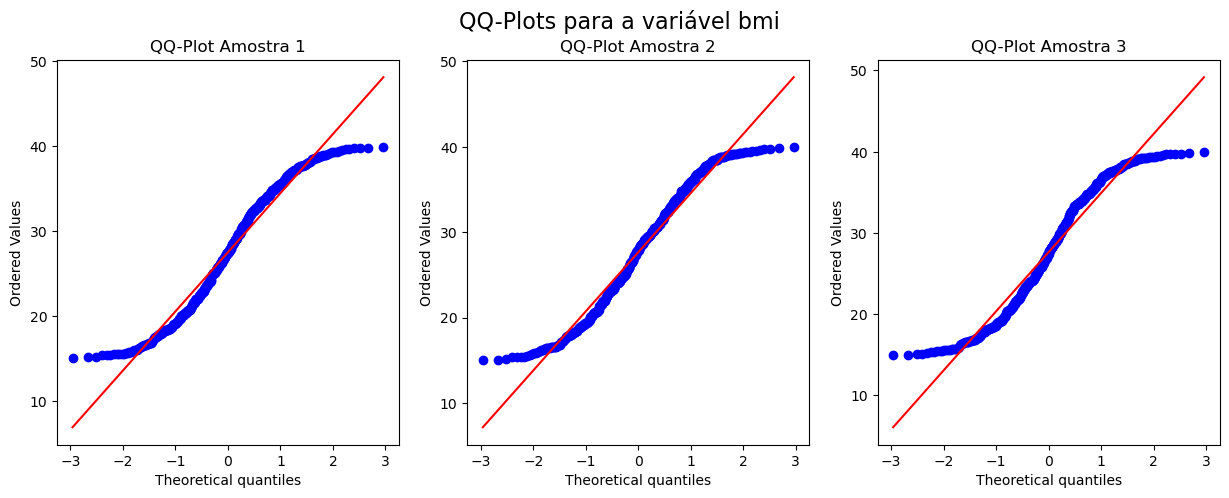

In [104]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[1]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[1]}", fontsize=16)
plt.show()

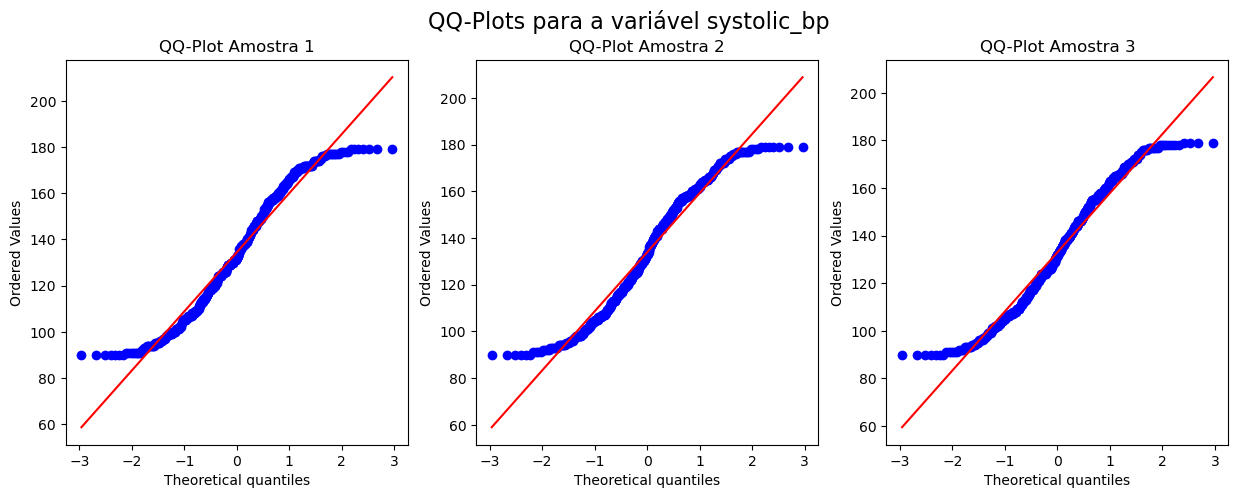

In [105]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[2]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[2]}", fontsize=16)
plt.show()

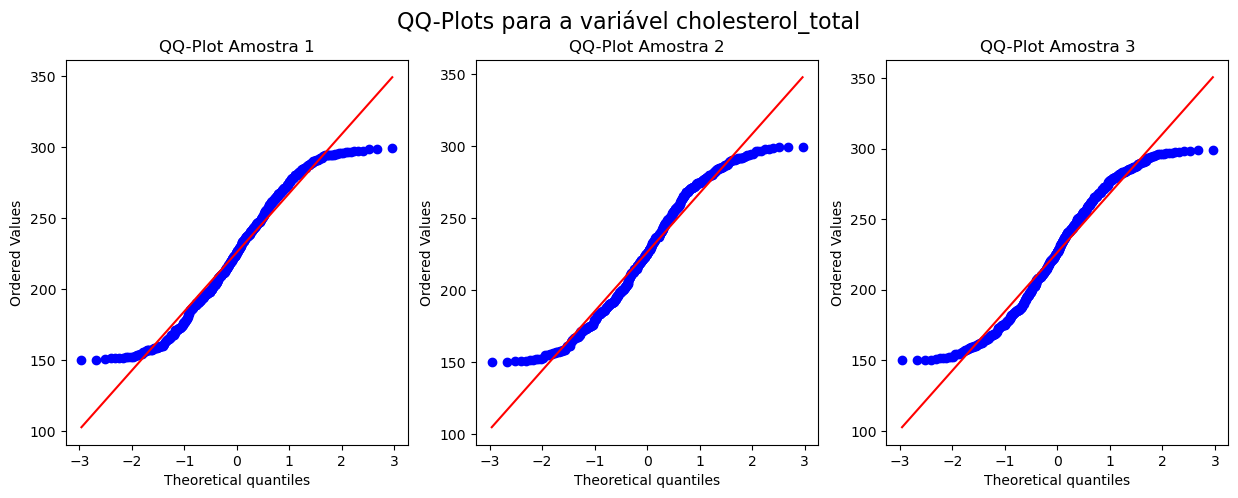

In [106]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[3]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[3]}", fontsize=16)
plt.show()

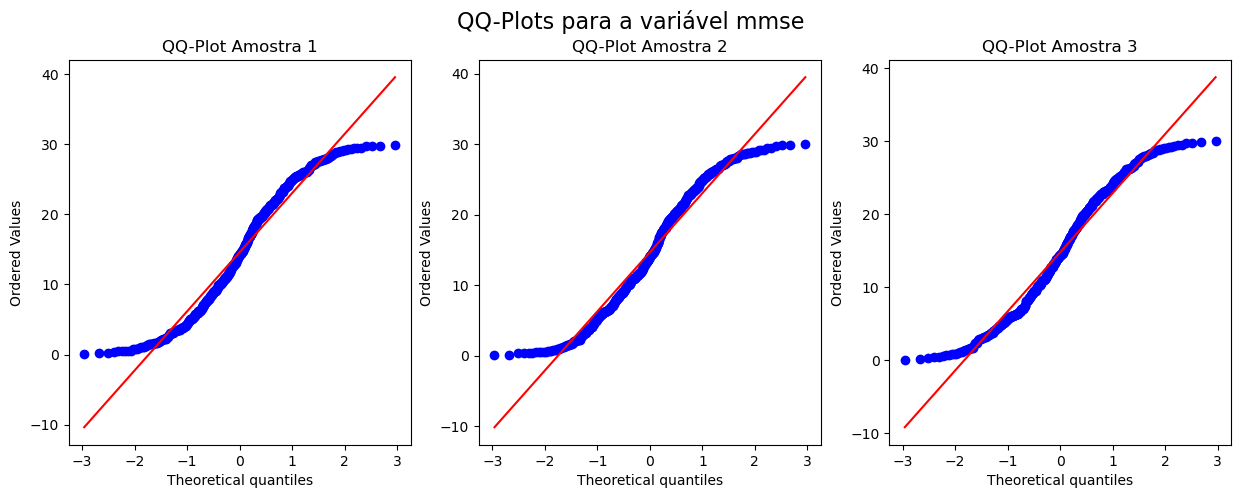

In [107]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[4]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[4]}", fontsize=16)
plt.show()

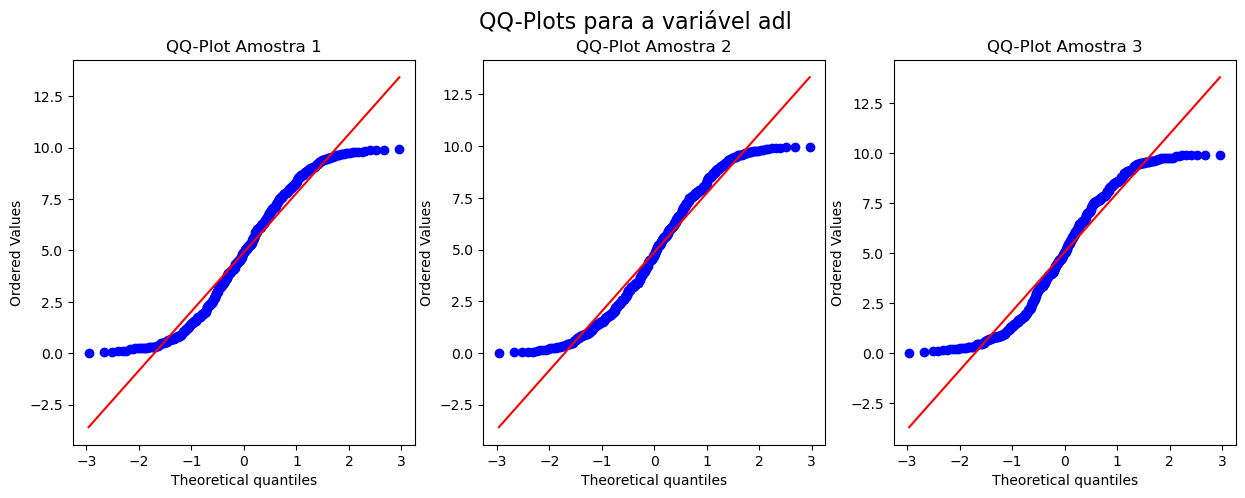

In [108]:
# QQ Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, amostra in enumerate(amostras):
    stats.probplot(amostra[main_columns[5]], dist="norm", plot=axs[i])
    axs[i].set_title(f"QQ-Plot Amostra {i+1}")
plt.suptitle(f"QQ-Plots para a variável {main_columns[5]}", fontsize=16)
plt.show()